# **WIND FARM ANAOMALY DETECTION SUITE**

![Renewable Energy](https://www.acciona.com.au/content/dam/accionaau/media/igamrjsj/renewables.jpg)



## Introduction

This notebook investigates anomaly detection techniques across three different wind farms (A, B, and C). The objective is to identify unusual or potentially problematic behavior within each wind farm's operational data and compare the effectiveness of different anomaly detection models in diverse scenarios.

## Methodology

The analysis follows a consistent approach for each wind farm:

1. **Data Loading and Preprocessing:**
    - Raw data is loaded from CSV files specific to each wind farm.
    - Basic data exploration and preprocessing are performed, including handling missing values and splitting the data into training and testing sets.
    - Features are scaled using StandardScaler.

2. **Anomaly Detection Models:**
    - **Isolation Forest:** This model is trained to identify anomalies based on isolation characteristics in the data.
    - **Autoencoder (AE):** An autoencoder is trained to learn a compressed representation of normal data. Anomalies are detected by comparing the reconstruction error of data points.
    - **Variational Autoencoder (VAE):** A VAE model is used for anomaly detection, similar to AE but includes a probabilistic latent space.
    - **Error Prediction Model (ANN):** A separate artificial neural network is trained to predict reconstruction errors and improve anomaly detection thresholds.

3. **Evaluation:**
    - Model performance is evaluated using metrics such as Precision, Recall, F1 Score, and Accuracy.
    - The CARE Score (Coverage, Accuracy, Reliability, Earliness) is calculated to assess the overall effectiveness of each model for each wind farm.

4. **Feature Selection with Random Forest:**
    - A Random Forest classifier is used to identify the most important features for anomaly detection.
    - Models are retrained using the top features for each wind farm.

5. **PCA Implementation:**
   - Principal Component Analysis (PCA) is applied for dimensionality reduction and potential model enhancement.
   - Anomaly detection models are trained and evaluated with PCA-transformed data for each wind farm.



# WIND FARM A

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import auc
from sklearn.metrics import average_precision_score
from sklearn.metrics import f1_score
from sklearn.metrics import recall_score
from sklearn.metrics import precision_score
from sklearn.ensemble import IsolationForest
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Input, Dense, GaussianNoise
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from care_score import CAREScore, Coverage, Accuracy, Reliability, Earliness
import tensorflow as tf
from sklearn.decomposition import PCA


## Preprocessing Functions


## Wind Farm A: Data Preprocessing

This section outlines the data preprocessing steps performed on the raw data for Wind Farm A, preparing it for model training and evaluation.

### 1. Data Loading:

- The raw data is loaded from a CSV file located at `/content/drive/MyDrive/Colab Notebooks/Wind_Farm_A/concatenated_output.csv`.
- The `load_data` function reads the data into a pandas DataFrame.

### 2. Data Cleaning:

- The `preprocess_data` function performs initial data exploration and checks for missing values.
- Missing values are handled using the `handle_missing_values` function, with the strategy set to 'drop' (removing rows with missing values). This ensures data quality and prevents issues during model training.

### 3. Data Splitting:

- The cleaned data is split into training and testing sets using the `split_train_test` function.
- This division allows for separate datasets to train the anomaly detection models and evaluate their performance on unseen data.

### 4. Feature Scaling:

- The `scale_features` function is applied to standardize the features using StandardScaler.
- This scaling ensures that features with different ranges do not disproportionately influence the models and improves model performance.

### 5. Feature Engineering:

- Specific columns deemed irrelevant for anomaly detection are dropped, including 'time_stamp', 'asset_id', 'id', 'train_test', 'status_type_id', and 'source'.
- This step focuses on selecting the most relevant features for anomaly detection.

### 6. Data Transformation (PCA):

- Principal Component Analysis (PCA) is applied to the scaled data using the `apply_pca` function.
- PCA reduces the dimensionality of the data while retaining most of the variance, which can potentially improve model efficiency and accuracy.

### 7. Feature Selection (Random Forest):
- A Random Forest Classifier is utilized to identify the top features contributing to anomaly detection.
- Models are subsequently retrained using these selected features, enhancing the focus on the most influential variables.

### Result:

After these preprocessing steps, the Wind Farm A data is transformed into a structured and cleaned format, suitable for training and evaluating various anomaly detection models. The selected features and scaled data ensure optimal model performance and reliable anomaly identification.

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

def load_data(file_path):
    """
    Load data from a CSV file.

    Parameters:
    file_path (str): Path to the CSV file

    Returns:
    pandas.DataFrame: Loaded data
    """
    try:
        df = pd.read_csv(file_path)
        print(f"Data loaded successfully. Shape: {df.shape}")
        return df
    except Exception as e:
        print(f"Error loading data: {e}")
        return None

def preprocess_data(df):
    """
    Perform basic preprocessing on the data.

    Parameters:
    df (pandas.DataFrame): Input DataFrame

    Returns:
    pandas.DataFrame: Preprocessed DataFrame
    """
    # Make a copy to avoid modifying the original DataFrame
    df_processed = df.copy()

    # Convert timestamp to datetime if it exists
    if 'time_stamp' in df_processed.columns:
        df_processed['time_stamp'] = pd.to_datetime(df_processed['time_stamp'], errors='coerce', format = 'mixed')
    # Get basic info about the data
    print("Data information:")
    print(f"Number of rows: {df_processed.shape[0]}")
    print(f"Number of columns: {df_processed.shape[1]}")
    print(f"Number of missing values: {df_processed.isnull().sum().sum()}")

    return df_processed

def handle_missing_values(df, strategy='drop'):
    """
    Handle missing values in the DataFrame.

    Parameters:
    df (pandas.DataFrame): Input DataFrame
    strategy (str): Strategy to handle missing values ('drop', 'mean', 'median', 'zero')

    Returns:
    pandas.DataFrame: DataFrame with handled missing values
    """
    # Make a copy to avoid modifying the original DataFrame
    df_clean = df.copy()

    # Print missing values before cleaning
    print("Missing values before cleaning:")
    print(df_clean.isnull().sum().sum())

    if strategy == 'drop':
        df_clean = df_clean.dropna()
    elif strategy == 'mean':
        numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
        df_clean[numeric_cols] = df_clean[numeric_cols].fillna(df_clean[numeric_cols].mean())
    elif strategy == 'median':
        numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
        df_clean[numeric_cols] = df_clean[numeric_cols].fillna(df_clean[numeric_cols].median())
    elif strategy == 'zero':
        df_clean = df_clean.fillna(0)

    # Print missing values after cleaning
    print("Missing values after cleaning:")
    print(df_clean.isnull().sum().sum())

    return df_clean

def split_train_test(df, train_label='train', test_label='prediction', split_column='train_test'):
    """
    Split the DataFrame into training and testing sets based on a specified column.

    Parameters:
    df (pandas.DataFrame): Input DataFrame
    train_label (str): Value in split_column that identifies training data
    test_label (str): Value in split_column that identifies testing data
    split_column (str): Column name to use for splitting

    Returns:
    tuple: (df_train, df_test) - Training and testing DataFrames
    """
    if split_column not in df.columns:
        raise ValueError(f"Column '{split_column}' not found in DataFrame")

    df_train = df[df[split_column] == train_label].copy()
    df_train = df_train[df_train['status_type_id']==0]
    df_test = df[df[split_column] == test_label].copy()
    df_test['status_type_id'] = df_test['status_type_id'].apply(lambda x: 0 if x in [0, 2] else 1)
    # df_test = df_train[df_train['status_type_id'].isin([0,4])]

    print(f"Training set shape: {df_train.shape}")
    print(f"Testing set shape: {df_test.shape}")

    return df_train, df_test

def prepare_features_and_labels(df, feature_columns=None, label_column=None):
    """
    Extract features and labels from the DataFrame.

    Parameters:
    df (pandas.DataFrame): Input DataFrame
    feature_columns (list): List of column names to use as features. If None, all columns except label_column are used.
    label_column (str): Column name to use as label. If None, no labels are returned.

    Returns:
    tuple: (X, y) - Features and labels (if label_column is provided, otherwise just X)
    """
    # If feature_columns is not provided, use all columns except label_column
    if feature_columns is None:
        if label_column is not None:
            feature_columns = [col for col in df.columns if col != label_column]
        else:
            feature_columns = df.columns.tolist()

    X = df[feature_columns].copy()

    if label_column is not None and label_column in df.columns:
        y = df[label_column].copy()
        return X, y
    else:
        return X

def scale_features(X_train, X_test=None, scaler_type='standard'):
    """
    Scale features using StandardScaler or MinMaxScaler.

    Parameters:
    X_train (pandas.DataFrame or numpy.ndarray): Training features
    X_test (pandas.DataFrame or numpy.ndarray): Testing features (optional)
    scaler_type (str): Type of scaler to use ('standard' or 'minmax')

    Returns:
    tuple: (X_train_scaled, X_test_scaled, scaler) - Scaled features and the fitted scaler
    """
    if scaler_type == 'standard':
        from sklearn.preprocessing import StandardScaler
        scaler = StandardScaler()
    elif scaler_type == 'minmax':
        from sklearn.preprocessing import MinMaxScaler
        scaler = MinMaxScaler()
    else:
        raise ValueError("scaler_type must be 'standard' or 'minmax'")

    X_train_scaled = scaler.fit_transform(X_train)

    if X_test is not None:
        X_test_scaled = scaler.transform(X_test)
        return X_train_scaled, X_test_scaled, scaler
    else:
        return X_train_scaled, scaler





def train_val_test_split(df_train, df_test, columns_to_drop, val_size=0.2, random_state=42):
    """
    Split data into training, validation, and test sets.

    Parameters:
    df_train (pandas.DataFrame): Training DataFrame
    df_test (pandas.DataFrame): Testing DataFrame
    columns_to_drop (list): Columns to drop from the features
    val_size (float): Proportion of training data to use for validation
    random_state (int): Random seed for reproducibility

    Returns:
    tuple: (X_train, X_val, X_test, feature_columns) - Feature sets and feature column names
    """
    # Store feature column names for reference
    feature_columns = [col for col in df_train.columns if col not in columns_to_drop]

    # Extract features
    X_train_full = df_train.drop(columns=columns_to_drop)
    X_test = df_test.drop(columns=columns_to_drop)

    # Split training data into train and validation sets
    X_train, X_val = train_test_split(X_train_full, test_size=val_size, random_state=random_state)

    print(f"X_train shape: {X_train.shape}")
    print(f"X_val shape: {X_val.shape}")
    print(f"X_test shape: {X_test.shape}")

    return X_train, X_val, X_test, feature_columns





def apply_pca(X_train, X_val, X_test, variance_threshold=0.90):
    """
    Applies PCA to the train, validation, and test datasets while retaining the specified variance.

    Parameters:
    - X_train: Training dataset (scaled).
    - X_val: Validation dataset (scaled).
    - X_test: Test dataset (scaled).
    - variance_threshold: The minimum variance to retain in the transformed data (default is 90%).

    Returns:
    - X_train_pca: PCA-transformed training data.
    - X_val_pca: PCA-transformed validation data.
    - X_test_pca: PCA-transformed test data.
    - pca: The trained PCA model (for inverse transform or further analysis).
    """
    # Fit PCA on the training data
    pca = PCA(n_components=variance_threshold)
    pca.fit(X_train)

    # Transform all datasets using the trained PCA
    X_train_pca = pca.transform(X_train)
    X_val_pca = pca.transform(X_val)
    X_test_pca = pca.transform(X_test)

    # Print how many components were selected
    print(f"PCA retained {pca.n_components_} components, preserving {variance_threshold*100}% variance.")

    return X_train_pca, X_val_pca, X_test_pca, pca


In [2]:
import os

from google.colab import drive
drive.mount('/content/drive')

base_path = '/content/drive/MyDrive/Colab Notebooks/Wind_Farm_A'
file_path = os.path.join(base_path, 'concatenated_output.csv')


Mounted at /content/drive


In [58]:
df = load_data(file_path)

Data loaded successfully. Shape: (1196747, 87)


In [25]:
df = preprocess_data(df)

Data information:
Number of rows: 1196747
Number of columns: 87
Number of missing values: 40


In [59]:
# Define columns to drop for feature engineering
columns_to_drop = ['time_stamp', 'asset_id', 'id', 'train_test', 'status_type_id', 'source']


# Handle missing values
df_clean = handle_missing_values(df, strategy='drop')

# Split data into train and test sets
df_train, df_test = split_train_test(df_clean)



# Split into train, validation, and test sets
X_train, X_val, X_test, feature_columns = train_val_test_split(
    df_train, df_test, columns_to_drop, val_size=0.2, random_state=42
)


# Scale the features
X_train_scaled, scaler = scale_features(X_train, scaler_type='standard')
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("\nPreprocessing completed. Data is ready for modeling.")

Missing values before cleaning:
40
Missing values after cleaning:
0
Training set shape: (859569, 87)
Testing set shape: (50589, 87)
X_train shape: (687655, 81)
X_val shape: (171914, 81)
X_test shape: (50589, 81)

Preprocessing completed. Data is ready for modeling.


### Preprocessing Summary:

- **Missing Values:** Initially, there were 40 missing values in the dataset. After cleaning, all missing values were removed.
- **Data Splitting:** The dataset was split into:
    - Training set: 859,569 samples
    - Testing set: 50,589 samples
- **Feature Engineering:** Irrelevant columns were dropped, resulting in 81 features for model training.
- **Final Data Shapes:**
    - X_train (training features): (687,655, 81)
    - X_val (validation features): (171,914, 81)
    - X_test (testing features): (50,589, 81)

In [ ]:
df_train.describe().T


,count,mean,std,min,25%,50%,75%,max
asset_id,859569.0,10.477983,6.874784,0.0,10.0,11.0,13.0,21.0
id,859569.0,26080.655348,15040.421445,0.0,13053.0,26245.0,38960.0,52322.0
status_type_id,859569.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
sensor_0_avg,859569.0,20.142852,5.365823,4.0,16.0,19.0,24.0,40.0
sensor_1_avg,859569.0,165.410468,88.950745,0.0,97.6,123.0,251.1,359.0
...,...,...,...,...,...,...,...,...
sensor_52_avg,859569.0,11.226181,4.624955,0.0,11.1,12.4,14.5,14.9
sensor_52_max,859569.0,12.144138,4.835514,0.0,11.5,14.2,15.0,19.6
sensor_52_min,859569.0,10.176567,4.577619,0.0,10.8,11.0,13.3,14.8
sensor_52_std,859569.0,0.460910,0.688958,0.0,0.1,0.3,0.6,7.4


In [27]:
# prompt: create a function that prints the mean, min, max, std of X_train_scaled, X_val_scaled, X_test_scaled and impement

import numpy as np
def print_stats(X_train_scaled, X_val_scaled, X_test_scaled):
  """Prints mean, min, max, and standard deviation of scaled datasets."""

  print("X_train_scaled Stats:")
  print("Mean:", np.mean(X_train_scaled))
  print("Min:", np.min(X_train_scaled))
  print("Max:", np.max(X_train_scaled))
  print("Std:", np.std(X_train_scaled))

  print("\nX_val_scaled Stats:")
  print("Mean:", np.mean(X_val_scaled))
  print("Min:", np.min(X_val_scaled))
  print("Max:", np.max(X_val_scaled))
  print("Std:", np.std(X_val_scaled))

  print("\nX_test_scaled Stats:")
  print("Mean:", np.mean(X_test_scaled))
  print("Min:", np.min(X_test_scaled))
  print("Max:", np.max(X_test_scaled))
  print("Std:", np.std(X_test_scaled))


# Assuming X_train_scaled, X_val_scaled, and X_test_scaled are already defined
print_stats(X_train_scaled, X_val_scaled, X_test_scaled)


X_train_scaled Stats:
Mean: -5.045783500457549e-16
Min: -813.0911490273447
Max: 40.69017052660669
Std: 0.9875771574795125

X_val_scaled Stats:
Mean: -0.0007506053164211201
Min: -10.600956564973144
Max: 40.69017052660669
Std: 0.9810893198119521

X_test_scaled Stats:
Mean: -0.04282781439761934
Min: -16.581624845851948
Max: 14.721021723855786
Std: 1.1346388771918994


## Model Training

## Model Training

This section details the training process for the anomaly detection models, including Isolation Forest, Autoencoder (AE), Variational Autoencoder (VAE), and Error Prediction Model (ANN). The functions defined here are designed to be reusable across all wind farm scenarios (A, B, and C), promoting consistency and streamlining the analysis.

### Model Training Functions:

- **`train_isolation_forest(X_train, contamination=0.1)`:** Trains an Isolation Forest model on the provided training data (`X_train`) with a specified contamination rate (default 0.1).
- **`build_autoencoder(input_dim, encoding_dim=44, noise=0.1)`:** Builds an autoencoder model architecture with specified input dimension (`input_dim`), encoding dimension (default 44), and noise level (default 0.1).
- **`train_autoencoder(model, X_train, X_val, epochs=100, batch_size=64)`:** Trains the provided autoencoder model using training data (`X_train`), validation data (`X_val`), and specified training parameters (epochs, batch size).
- **`build_vae(input_dim, encoding_dim=44, latent_dim=4)`:** Builds a Variational Autoencoder (VAE) model architecture with specified input dimension (`input_dim`), encoding dimension (default 44), and latent dimension (default 4).
- **`train_vae(model, X_train, X_val, epochs=100, batch_size=64)`:** Trains the provided VAE model using training data (`X_train`), validation data (`X_val`), and specified training parameters (epochs, batch size).
- **`build_error_prediction_model(input_dim, units1=20, units2=36, units3=36, learning_rate=0.0056)`:** Builds an error prediction model architecture, typically an ANN, to predict reconstruction errors.
- **`train_error_prediction_model(model, X_train, y_train, X_val, y_val, epochs=100, batch_size=64)`:** Trains the error prediction model using training data (`X_train`, `y_train`), validation data (`X_val`, `y_val`), and specified training parameters (epochs, batch size).
- **`plot_training_history(history)`:** Plots the training history of a model, showing training and validation loss over epochs.

### Reusability Across Wind Farms:

These functions are designed to be applied to the preprocessed data from each wind farm. The input data (`X_train`, `X_val`, `X_test`) will be specific to each wind farm, but the functions themselves remain the same. This ensures a consistent model training approach and facilitates direct comparisons of model performance across different wind farm scenarios.



In [45]:
# Function to train Isolation Forest
def train_isolation_forest(X_train, contamination=0.1):
    model = IsolationForest(contamination=contamination, random_state=42)
    model.fit(X_train)
    return model

# Function to build an Autoencoder
def build_autoencoder(input_dim, encoding_dim=44, noise=0.1):
    input_layer = Input(shape=(input_dim,))
    encoded = GaussianNoise(noise)(input_layer)
    encoded = Dense(encoding_dim, activation='relu')(encoded)
    encoded = Dense(25, activation='relu')(encoded)
    encoded = Dense(4, activation='relu')(encoded)
    decoded = Dense(25, activation='relu')(encoded)
    decoded = Dense(encoding_dim, activation='relu')(decoded)
    decoded = Dense(input_dim, activation='sigmoid')(decoded)
    model = Model(input_layer, decoded)
    model.compile(optimizer=Adam(learning_rate=0.0018), loss='mse')
    return model

# Function to train an Autoencoder
def train_autoencoder(model, X_train, X_val, epochs=100, batch_size=64):
    early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    history = model.fit(
        X_train, X_train, epochs=epochs, batch_size=batch_size,
        shuffle=True, validation_data=(X_val, X_val), callbacks=[early_stopping]
    )
    return history

# Function to build a Variational Autoencoder (VAE)
def build_vae(input_dim, encoding_dim=44, latent_dim=4):
    from tensorflow.keras.layers import Layer
    import tensorflow as tf

    class Sampling(Layer):
        def call(self, inputs):
            z_mean, z_log_var = inputs
            batch = tf.shape(z_mean)[0]
            dim = tf.shape(z_mean)[1]
            epsilon = tf.random.normal(shape=(batch, dim))
            return z_mean + tf.exp(0.5 * z_log_var) * epsilon

    class VAE(Model):
        def __init__(self, input_dim, encoding_dim=44, latent_dim=4, **kwargs):
            super(VAE, self).__init__(**kwargs)
            self.input_dim = input_dim
            self.encoding_dim = encoding_dim
            self.latent_dim = latent_dim
            self.noise_layer = GaussianNoise(0.1)
            self.encoder_dense1 = Dense(encoding_dim, activation='relu')
            self.encoder_dense2 = Dense(10, activation='relu')
            self.z_mean = Dense(latent_dim)
            self.z_log_var = Dense(latent_dim)
            self.sampling = Sampling()
            self.decoder_dense1 = Dense(10, activation='relu')
            self.decoder_dense2 = Dense(encoding_dim, activation='relu')
            self.decoder_output = Dense(input_dim, activation='sigmoid')

        def encode(self, inputs):
            x = self.noise_layer(inputs)
            x = self.encoder_dense1(x)
            x = self.encoder_dense2(x)
            z_mean = self.z_mean(x)
            z_log_var = self.z_log_var(x)
            z = self.sampling([z_mean, z_log_var])
            return z_mean, z_log_var, z

        def decode(self, z):
            x = self.decoder_dense1(z)
            x = self.decoder_dense2(x)
            return self.decoder_output(x)

        def call(self, inputs):
            z_mean, z_log_var, z = self.encode(inputs)
            reconstructed = self.decode(z)
            kl_loss = -0.5 * tf.reduce_mean(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
            self.add_loss(kl_loss)
            return reconstructed

    vae = VAE(input_dim=input_dim)
    vae.compile(optimizer=Adam(learning_rate=0.001))
    return vae

# Function to train a VAE
def train_vae(model, X_train, X_val, epochs=100, batch_size=64):
    early_stopping = EarlyStopping(monitor='loss', patience=10, restore_best_weights=True)
    history = model.fit(X_train, epochs=epochs, batch_size=batch_size, shuffle=True, validation_data=(X_val,), callbacks=[early_stopping])
    return history

# # Function to build an error prediction model
# def build_error_prediction_model(input_dim, units1=62, units2=97, learning_rate=0.0056):
#     model = Sequential([
#         Dense(units1, input_dim=input_dim, activation='relu'),
#         Dense(units2, activation='relu'),
#         Dense(1, activation='linear')
#     ])
#     model.compile(optimizer=Adam(learning_rate=learning_rate), loss='mse')
#     return model

# Function to build an error prediction model
def build_error_prediction_model(input_dim, units1=20, units2=36, units3 = 36, learning_rate=0.0056):
    model = Sequential([
        Dense(units1, input_dim=input_dim, activation='relu'),
        Dense(units2, activation='relu'),
        Dense(units3, activation='relu'),
        Dense(1, activation='linear')
    ])
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss='mse')
    return model


# Function to train an error prediction model
def train_error_prediction_model(model, X_train, y_train, X_val, y_val, epochs=100, batch_size=64):
    early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    history = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, shuffle=True, validation_data=(X_val, y_val), callbacks=[early_stopping])
    return history

# Function to plot training history
def plot_training_history(history):
    plt.figure(figsize=(10, 6))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Training Loss vs Validation Loss')
    plt.legend()
    plt.show()

### ISOLATION FOREST

In [ ]:
iso_forest = train_isolation_forest(X_train_scaled, contamination=0.1)
iso_anomalies = iso_forest.predict(X_test_scaled)
df_test['iso_anomaly'] = (iso_anomalies == -1).astype(int)


### AE

In [ ]:
input_dim = X_train_scaled.shape[1]
autoencoder = build_autoencoder(input_dim)
history_ae = train_autoencoder(autoencoder, X_train_scaled, X_val_scaled)

# Plot training loss
plot_training_history(history_ae)

# Get reconstruction error
X_test_reconstructed = autoencoder.predict(X_test_scaled)
reconstruction_error = np.mean(np.square(X_test_scaled - X_test_reconstructed), axis=1)


In [ ]:
from tensorflow.keras.models import load_model

# Load the autoencoder model
autoencoder = load_model('autoencoder_model.keras')
ann_model = load_model('ann_model.keras')


### VAE

Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/optimizers/base_optimizer.py:774: UserWarning: Gradients do not exist for variables ['vae/dense_4/kernel', 'vae/dense_4/bias', 'vae/dense_5/kernel', 'vae/dense_5/bias', 'vae/dense_6/kernel', 'vae/dense_6/bias'] when minimizing the loss. If using `model.compile()`, did you forget to provide a `loss` argument?
  warnings.warn(


10745/10745 ━━━━━━━━━━━━━━━━━━━━ 45s 4ms/step - loss: 0.0037 - val_loss: 9.5246e-10
Epoch 2/100
10745/10745 ━━━━━━━━━━━━━━━━━━━━ 71s 3ms/step - loss: 9.6506e-08 - val_loss: 1.5196e-09
Epoch 3/100
10745/10745 ━━━━━━━━━━━━━━━━━━━━ 47s 3ms/step - loss: 3.2732e-09 - val_loss: 2.3719e-08
Epoch 4/100
10745/10745 ━━━━━━━━━━━━━━━━━━━━ 49s 5ms/step - loss: 3.8117e-11 - val_loss: 2.3722e-08
Epoch 5/100
10745/10745 ━━━━━━━━━━━━━━━━━━━━ 67s 3ms/step - loss: 3.0101e-11 - val_loss: 2.3718e-08
Epoch 6/100
10745/10745 ━━━━━━━━━━━━━━━━━━━━ 36s 3ms/step - loss: 2.7743e-11 - val_loss: 2.3722e-08
Epoch 7/100
10745/10745 ━━━━━━━━━━━━━━━━━━━━ 47s 4ms/step - loss: 2.9033e-11 - val_loss: 2.3720e-08
Epoch 8/100
10745/10745 ━━━━━━━━━━━━━━━━━━━━ 53s 5ms/step - loss: 3.4291e-11 - val_loss: 2.3720e-08
Epoch 9/100
10745/10745 ━━━━━━━━━━━━━━━━━━━━ 63s 6ms/step - loss: 2.5045e-11 - val_loss: 2.3719e-08
Epoch 10/100
10745/10745 ━━━━━━━━━━━━━━━━━━━━ 80s 6ms/step - loss: 3.2280e-11 - val_loss: 2.3718e-08
Epoch 11/100
10

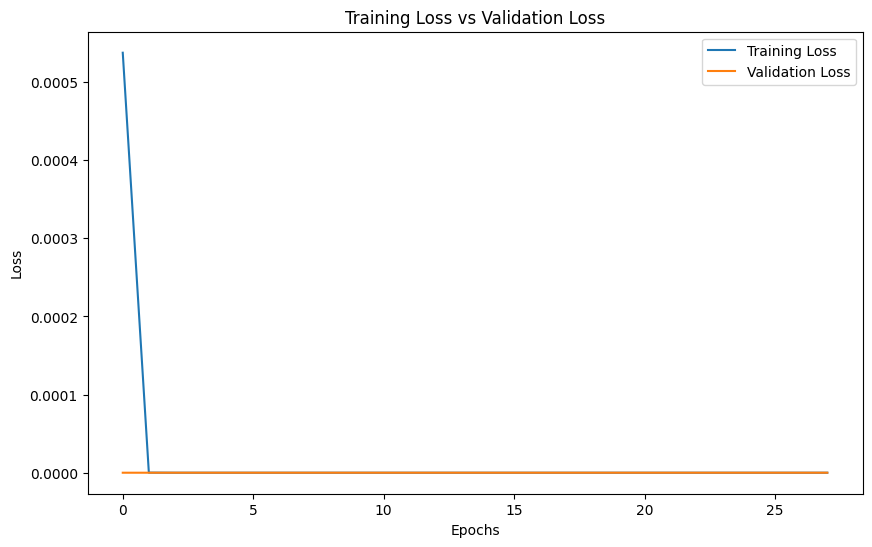

1581/1581 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


In [11]:
input_dim = X_train_scaled.shape[1]

vae = build_vae(input_dim)
history_vae = train_vae(vae, X_train_scaled, X_val_scaled)

# Plot training loss
plot_training_history(history_vae)

# Get VAE reconstruction error
X_test_reconstructed = vae.predict(X_test_scaled)
vae_reconstruction_error = np.mean(np.square(X_test_scaled - X_test_reconstructed), axis=1)


In [12]:
import keras

In [13]:
vae.save('/content/drive/MyDrive/Colab Notebooks/Wind_Farm_A/vae_wa.keras')

In [ ]:
# vae = load_model('/content/vae_model.keras')
# # vae = keras.models.load_model('vae_model.keras',
#                             #  custom_objects={'VAE': VAE, 'Sampling': Sampling})
# vae_ann_model = load_model('ann_vae.keras')

TypeError: Could not locate class 'VAE'. Make sure custom classes are decorated with `@keras.saving.register_keras_serializable()`. Full object config: {'module': None, 'class_name': 'VAE', 'config': {'name': 'vae', 'trainable': True, 'dtype': {'module': 'keras', 'class_name': 'DTypePolicy', 'config': {'name': 'float32'}, 'registered_name': None}}, 'registered_name': 'VAE', 'build_config': {'input_shape': [None, 81]}, 'compile_config': {'optimizer': {'module': 'keras.optimizers', 'class_name': 'Adam', 'config': {'name': 'adam', 'learning_rate': 0.0010000000474974513, 'weight_decay': None, 'clipnorm': None, 'global_clipnorm': None, 'clipvalue': None, 'use_ema': False, 'ema_momentum': 0.99, 'ema_overwrite_frequency': None, 'loss_scale_factor': None, 'gradient_accumulation_steps': None, 'beta_1': 0.9, 'beta_2': 0.999, 'epsilon': 1e-07, 'amsgrad': False}, 'registered_name': None}, 'loss': None, 'loss_weights': None, 'metrics': None, 'weighted_metrics': None, 'run_eagerly': False, 'steps_pe

## EVALUATION

## Evaluation

This section outlines the evaluation process for the anomaly detection models, focusing on metrics and techniques used to assess their performance.

### Evaluation Metrics:

The following metrics are used to evaluate the performance of the anomaly detection models:

- **Precision:** Measures the proportion of correctly identified anomalies among all predicted anomalies.
- **Recall:** Measures the proportion of correctly identified anomalies among all actual anomalies.
- **F1 Score:** A harmonic mean of precision and recall, providing a balanced measure of performance.
- **Accuracy:** Measures the overall correctness of the model's predictions.
- **CARE Score:** (Coverage, Accuracy, Reliability, Earliness) is a composite metric that considers multiple aspects of anomaly detection performance.


### Evaluation Functions:

- `detect_anomalies_isolation_forest(model, X_test)`: Detects anomalies using a trained Isolation Forest model.
- `calculate_vae_reconstruction_error(vae, X)`: Calculates reconstruction error for the VAE model.
- `calculate_reconstruction_error(model, X)`: Calculates reconstruction error for autoencoder models.
- `detect_anomalies_autoencoder(autoencoder, error_model, X_test, gamma=0.34)`: Detects anomalies using the autoencoder + error prediction model approach.
- `evaluate_anomaly_detection(y_true, y_pred)`: Evaluates anomaly detection performance using precision, recall, F1, and accuracy.
- `calculate_care_score(df_test, anomaly_column)`: Calculates CARE Score (Coverage, Accuracy, Reliability, Earliness) for an anomaly detection model.


### Evaluation Procedure:

1. **Anomaly Detection:** Predictions are made using the trained models on the testing data.
2. **Metric Calculation:** The evaluation metrics are calculated to quantify the performance of each model.
3. **CARE Score Calculation:** The CARE Score is calculated to assess the model's overall performance according to the Care to Compare Paper.
4. **Comparison and Analysis:** The results are compared and analyzed to identify the best-performing models for each wind farm scenario.

The evaluation section provides a comprehensive assessment of the models' performance, aiding in the selection of the most effective anomaly detection approach for each wind farm scenario.

In [40]:
def detect_anomalies_isolation_forest(model, X_test):
    """Detects anomalies using a trained Isolation Forest model."""
    iso_anomalies = model.predict(X_test)
    return (iso_anomalies == -1).astype(int)  # Convert -1 (anomaly) to 1, and 1 (normal) to 0


def calculate_vae_reconstruction_error(vae, X):
    """Calculates reconstruction error for the VAE model."""
    reconstructed = vae(X)  # This uses the call method which returns reconstructions
    return tf.reduce_mean(tf.square(X - reconstructed), axis=1).numpy()


def calculate_reconstruction_error(model, X):
    """Calculates reconstruction error for autoencoder models."""
    X_reconstructed = model.predict(X)
    return np.mean(np.square(X - X_reconstructed), axis=1)


def detect_anomalies_autoencoder(autoencoder, error_model, X_test, gamma=0.34):
    """
    Detects anomalies using the autoencoder + error prediction model approach.
    An anomaly is detected if the reconstruction error exceeds the predicted threshold.
    """
    reconstruction_error = calculate_reconstruction_error(autoencoder, X_test)
    predicted_threshold = error_model.predict(X_test).flatten()
    anomalies = reconstruction_error > (predicted_threshold + gamma)
    return anomalies.astype(int)


def evaluate_anomaly_detection(y_true, y_pred):
    """Evaluates anomaly detection performance using precision, recall, F1, and accuracy."""
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    accuracy = accuracy_score(y_true, y_pred)

    return {
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "Accuracy": accuracy
    }


def calculate_care_score(df_test, anomaly_column):
    """
    Calculates CARE Score (Coverage, Accuracy, Reliability, Earliness) for an anomaly detection model.
    """
    df_care = df_test.copy()
    df_care.rename(columns={'status_type_id': 'status_id', anomaly_column: 'anomaly'}, inplace=True)

    df_care['anomaly'] = df_care['anomaly'].apply(lambda x: 0 if x == -1 else x)
    df_care['status_id'] = df_care['status_id'].apply(lambda x: 'normal' if x in [0, 2] else 'not normal')

    anomaly_results = pd.DataFrame({'anomaly': df_care['anomaly']}, index=df_care.index)

    coverage_score = Coverage(beta=0.5).calculate_coverage_score(df_care, anomaly_results)
    accuracy_score = Accuracy().calculate_accuracy_score(df_care, anomaly_results)
    reliability_score = Reliability().calculate_reliability_score(df_care, anomaly_results)
    earliness_score = Earliness().calculate_earliness_score(df_care, anomaly_results)
    care_evaluator = CAREScore(omega1=1.0, omega2=1.0, omega3=1.0, omega4=2.0)
    care_scores = care_evaluator.calculate_care_score(df_care, anomaly_results)


    return care_scores


21490/21490 ━━━━━━━━━━━━━━━━━━━━ 31s 1ms/step
5373/5373 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step
Epoch 1/30


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2149/2149 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 0.0470 - val_loss: 0.0110
Epoch 2/30
2149/2149 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.0105 - val_loss: 0.0079
Epoch 3/30
2149/2149 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 0.0159 - val_loss: 0.0062
Epoch 4/30
2149/2149 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - loss: 0.0113 - val_loss: 0.0053
Epoch 5/30
2149/2149 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.0054 - val_loss: 0.0042
Epoch 6/30
2149/2149 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - loss: 0.0078 - val_loss: 0.0150
Epoch 7/30
2149/2149 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - loss: 0.0095 - val_loss: 0.0041
Epoch 8/30
2149/2149 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 0.0069 - val_loss: 0.0028
Epoch 9/30
2149/2149 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 0.0069 - val_loss: 0.0102
Epoch 10/30
2149/2149 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.0074 - val_loss: 0.0032
Epoch 11/30
2149/2149 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - loss: 0.0130 - val_loss: 0.0107
Epoch 12/30
2149/2149 ━━━━━━━━━━━━━━━

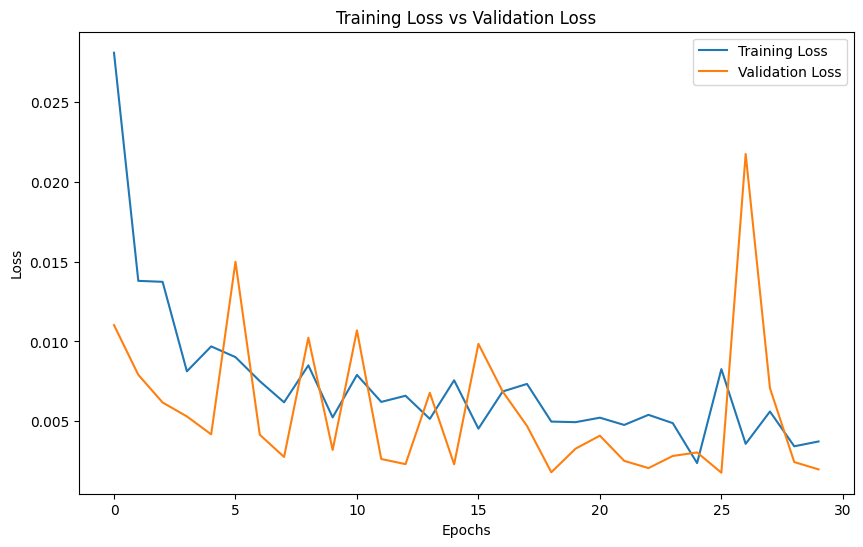

In [15]:
X_train_reconstruction_error = calculate_reconstruction_error(vae, X_train_scaled)
X_val_reconstruction_error = calculate_reconstruction_error(vae, X_val_scaled)


X_train_val, X_val_val, y_train_val, y_val_val = train_test_split(
    X_val_scaled, X_val_reconstruction_error, test_size=0.2, random_state=42
)

input_dim = X_train_scaled.shape[1]

ann_vae = build_error_prediction_model(input_dim)


history_ann = train_error_prediction_model(
    ann_vae, X_train_val, y_train_val, X_val_val, y_val_val, epochs=30
)

plot_training_history(history_ann)


In [ ]:
df_test['iso_anomaly'] = detect_anomalies_isolation_forest(iso_forest, X_test_scaled)
df_test['ae_reconstruction_error'] = calculate_reconstruction_error(autoencoder, X_test_scaled)


# df_test['ae_anomaly'] = detect_anomalies_autoencoder(autoencoder, ann_model, X_test_scaled, gamma=0.1)
#



1581/1581 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step


In [ ]:
df_test['ae_anomaly'] = detect_anomalies_autoencoder(autoencoder, ann_model, X_test_scaled, gamma=0.019)

1581/1581 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step
1581/1581 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


In [18]:
y_true = (df_test['status_type_id'] != 0).astype(int)

In [ ]:
print("Isolation Forest Evaluation:")
print(evaluate_anomaly_detection(y_true, df_test['iso_anomaly']))

print("\nAutoencoder Evaluation:")
print(evaluate_anomaly_detection(y_true, df_test['ae_anomaly']))

Isolation Forest Evaluation:
{'Precision': 0.4558756287151349, 'Recall': 0.4336668116572423, 'F1 Score': 0.444493981275078, 'Accuracy': 0.7537013975370139}

Autoencoder Evaluation:
{'Precision': 0.19729950900163667, 'Recall': 0.41948673336233144, 'F1 Score': 0.2683734520662307, 'Accuracy': 0.48030204194587756}


In [33]:
# df_test['vae_reconstruction_error'] = calculate_reconstruction_error(vae, X_test_scaled)

df_test['vae_anomaly'] = detect_anomalies_autoencoder(vae, ann_vae, X_test_scaled, gamma=0)

print("\nVAE Evaluation:")
print(evaluate_anomaly_detection(y_true, df_test['vae_anomaly']))

print("\nVAE CARE Score:")
vae_care_scores = calculate_care_score(df_test, 'vae_anomaly')
print(vae_care_scores)

1581/1581 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
1581/1581 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step

VAE Evaluation:
{'Precision': 0.20245820619708627, 'Recall': 0.40983036102653325, 'F1 Score': 0.27102749971234613, 'Accuracy': 0.4990610607048963}

VAE CARE Score:
{'coverage': np.float64(0.776393421009262), 'accuracy': np.float64(0.5252979996930476), 'reliability': np.float64(0.2687618949642508), 'earliness': np.float64(0.401852769128094), 'care': np.float64(0.47483177078454963)}


In [ ]:
print("Isolation Forest CARE Score:")
iso_care_scores = calculate_care_score(df_test, 'iso_anomaly')
print(iso_care_scores)

print("\nAutoencoder CARE Score:")
ae_care_scores = calculate_care_score(df_test, 'ae_anomaly')
print(ae_care_scores)


Isolation Forest CARE Score:
{'coverage': np.float64(0.7929059965007158), 'accuracy': np.float64(0.8478027318770144), 'reliability': np.float64(0.2687618949642508), 'earliness': np.float64(0.6068677496912714), 'care': np.float64(0.6246412245449047)}

Autoencoder CARE Score:
{'coverage': np.float64(0.7832245070331026), 'accuracy': np.float64(0.4981838645316417), 'reliability': np.float64(0.2687618949642508), 'earliness': np.float64(0.4566936051342612), 'care': np.float64(0.4981838645316417)}


In [37]:
ae_care_scores = {'coverage': np.float64(0.7832245070331026), 'accuracy': np.float64(0.4981838645316417), 'reliability': np.float64(0.2687618949642508), 'earliness': np.float64(0.4566936051342612), 'care': np.float64(0.4981838645316417)}

iso_care_scores = {'coverage': np.float64(0.7929059965007158), 'accuracy': np.float64(0.8478027318770144), 'reliability': np.float64(0.2687618949642508), 'earliness': np.float64(0.6068677496912714), 'care': np.float64(0.6246412245449047)}

vae_care_scores = {'coverage': np.float64(0.776393421009262), 'accuracy': np.float64(0.5252979996930476), 'reliability': np.float64(0.2687618949642508), 'earliness': np.float64(0.401852769128094), 'care': np.float64(0.47483177078454963)}

## Anomaly Detection Workflow with AE, VAE, and ANN

This section explains the workflow for identifying anomalies in data using Autoencoders (AE), Variational Autoencoders (VAE), and Artificial Neural Networks (ANN).

**1. Data Preprocessing:**

- Prepare the data by:
    - Scaling features to a common range.
    - Handling missing values appropriately (e.g., imputation or removal).
    - Splitting the data into training, validation, and testing sets.

**2. Model Training:**

- **AE/VAE Training:**
    - Train an AE or VAE on the training data.
    - The model learns to reconstruct the input data with minimal error, capturing the essence of "normal" data patterns.
- **ANN Training (Error Prediction Model):**
    - Train a separate ANN on the validation data.
    - This ANN learns to predict the reconstruction error of the AE/VAE for normal data points.
    - It provides an estimated threshold for distinguishing anomalies.

**3. Anomaly Detection:**

- **Reconstruction Error Calculation:**
    - Use the trained AE/VAE to reconstruct the testing data.
    - Calculate the reconstruction error for each data point in the testing set.
- **Threshold Determination:**
    - Utilize the trained ANN to predict the reconstruction error threshold for normal data.
    - This threshold represents the expected error for non-anomalous data points.
- **Anomaly Identification:**
    - Compare the reconstruction error of each testing data point to the predicted threshold.
    - If the reconstruction error exceeds the threshold by a significant margin (gamma), flag the data point as an anomaly.

**Simplified Explanation:**

1. The AE/VAE learns to represent and reconstruct "normal" data effectively.
2. The ANN learns to estimate the expected reconstruction error for normal data.
3. Data points with significantly higher reconstruction errors than expected are identified as anomalies.

**AE vs. VAE:**

- **AE:** Uses a deterministic approach, focusing on minimizing reconstruction error.
- **VAE:** Employs a probabilistic approach, learning a distribution of normal data and identifying deviations.

**Role of ANN:**

- The ANN refines the anomaly detection threshold by learning from the validation data, improving accuracy and robustness.



## Model Comparison

In [38]:
def plot_care_scores(*care_scores_and_models):
  """
  Plots CARE scores for multiple anomaly detection models.

  Args:
    *care_scores_and_models: Variable number of arguments, where each argument is a tuple
                            containing (care_scores, model_name).
                            e.g., (iso_care_scores, 'Isolation Forest'), (ae_care_scores, 'Autoencoder')
  """

  # Extract care scores and model names
  care_scores = [scores for scores, _ in care_scores_and_models]
  models = [model_name for _, model_name in care_scores_and_models]

  # Get CARE metrics from the first care score dictionary (assuming all have the same metrics)
  care_metrics = list(care_scores[0].keys())

  # Create plot
  fig, ax = plt.subplots(figsize=(10, 6))
  num_models = len(care_scores)
  width = 0.8 / num_models  # Adjust width based on the number of models
  x = np.arange(len(care_metrics))

  # for i, model in enumerate(models):
  #     ax.bar(x + i * width, [care_scores[i][metric] for metric in care_metrics], width, label=model)

  for i, model in enumerate(models):
      rects = ax.bar(x + i * width, [care_scores[i][metric] for metric in care_metrics], width, label=model)

      # Add data labels
      for rect in rects:
          height = rect.get_height()
          ax.text(rect.get_x() + rect.get_width() / 2, height,
                  f'{height:.2f}', ha='center', va='bottom')

  # Set plot labels and title
  ax.set_xticks(x + width * (num_models - 1) / 2)  # Center x-axis ticks
  ax.set_xticklabels(care_metrics)
  ax.set_ylabel('CARE Score')
  ax.set_title('CARE Score Comparison for Anomaly Detection Models')
  ax.legend()

  plt.tight_layout()
  plt.show()

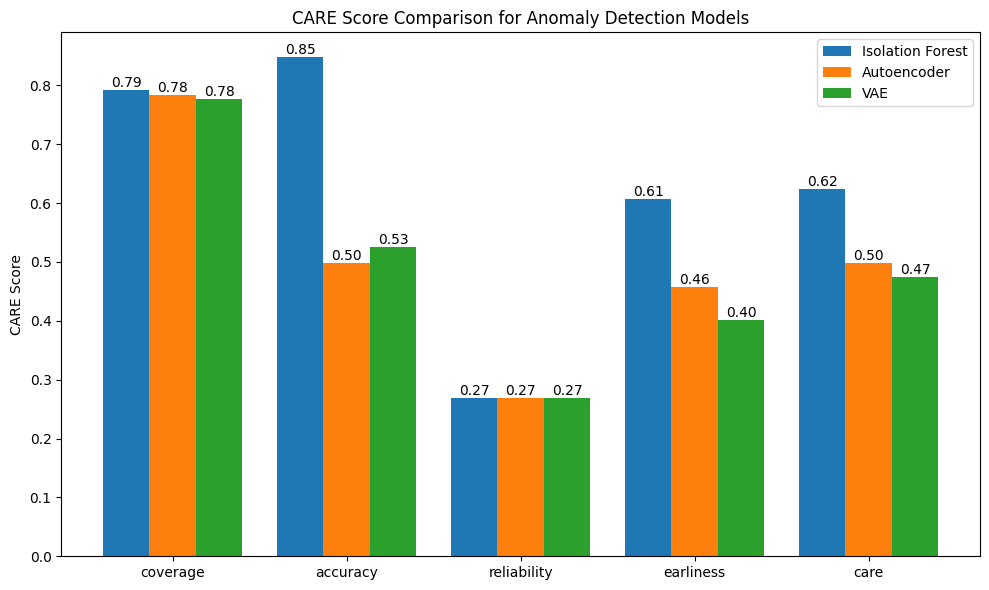

In [39]:
# Example usage:
plot_care_scores(
    (iso_care_scores, 'Isolation Forest'),
    (ae_care_scores, 'Autoencoder')
    ,
    (vae_care_scores, 'VAE')
)

## Wind Farm A: Model Performance on All Data - Interpretation of CARE Scores

The table below presents the CARE scores for Isolation Forest, Autoencoder, and Variational Autoencoder when trained on all data from Wind Farm A:

| Model | Coverage | Accuracy | Reliability | Earliness | Care |
|---|---|---|---|---|---|
| Isolation Forest | 0.79 | 0.85 | 0.27 | 0.61 | 0.62 |
| Autoencoder | 0.78 | 0.5 | 0.27 | 0.46 | 0.5 |
| Variational Autoencoder | 0.78 | 0.53 | 0.27 | 0.4 | 0.47 |


**Interpretation:**

* **Isolation Forest** demonstrates the best overall performance with the highest **Care** score (0.62). This indicates a good balance between anomaly detection capabilities (**Coverage**, **Earliness**) and minimizing false alarms (**Reliability**). It also exhibits high **Accuracy**, suggesting its ability to recognize normal behavior effectively.
* **Autoencoder** and **Variational Autoencoder** have lower **Care** scores, indicating relatively weaker performance. While their **Coverage** is comparable to Isolation Forest, they struggle with **Accuracy**, **Reliability**, and **Earliness**. This suggests a higher tendency to generate false alarms and potentially miss anomalies or detect them later.
* **Reliability** is consistently low across all models (0.27), implying a common challenge in minimizing false alarms in this scenario. This aspect might require further investigation and potential model adjustments.
* **Earliness** is relatively better for Isolation Forest (0.61), highlighting its ability to detect anomalies earlier than other models.
* **Coverage** is comparable across all models, indicating a similar ability to detect a good proportion of anomalies.

Based on the CARE scores, **Isolation Forest** appears to be the most promising anomaly detection model for Wind Farm A when trained on all data. However, addressing the low **Reliability** scores across all models remains a crucial area for improvement. Further analysis and model fine-tuning could potentially enhance the overall performance and reduce false alarms.

## PCA Implementation

In [41]:
X_train_pca, X_val_pca, X_test_pca, pca_model = apply_pca(X_train_scaled, X_val_scaled, X_test_scaled)


PCA retained 11 components, preserving 90.0% variance.


### ISO PCA

In [32]:
iso_forest = train_isolation_forest(X_train_pca, contamination=0.1)
iso_anomalies = iso_forest.predict(X_test_pca)
df_test['iso_pca_anomaly'] = (iso_anomalies == -1).astype(int)

### AE PCA

In [ ]:
input_dim = X_train_pca.shape[1]
autoencoder_pca = build_autoencoder(input_dim)
history_ae = train_autoencoder(autoencoder_pca, X_train_pca, X_val_pca, epochs=30)



Epoch 1/30
10745/10745 ━━━━━━━━━━━━━━━━━━━━ 35s 3ms/step - loss: 5.5374 - val_loss: 5.3814
Epoch 2/30
10745/10745 ━━━━━━━━━━━━━━━━━━━━ 33s 3ms/step - loss: 5.3698 - val_loss: 5.3140
Epoch 3/30
10745/10745 ━━━━━━━━━━━━━━━━━━━━ 39s 3ms/step - loss: 5.3869 - val_loss: 5.3090
Epoch 4/30
10745/10745 ━━━━━━━━━━━━━━━━━━━━ 44s 3ms/step - loss: 5.3528 - val_loss: 5.2887
Epoch 5/30
10745/10745 ━━━━━━━━━━━━━━━━━━━━ 42s 3ms/step - loss: 5.3878 - val_loss: 5.2862
Epoch 6/30
10745/10745 ━━━━━━━━━━━━━━━━━━━━ 39s 4ms/step - loss: 5.3202 - val_loss: 5.2689
Epoch 7/30
10745/10745 ━━━━━━━━━━━━━━━━━━━━ 34s 3ms/step - loss: 5.3460 - val_loss: 5.2677
Epoch 8/30
10745/10745 ━━━━━━━━━━━━━━━━━━━━ 42s 3ms/step - loss: 5.3339 - val_loss: 5.2676
Epoch 9/30
10745/10745 ━━━━━━━━━━━━━━━━━━━━ 40s 3ms/step - loss: 5.2679 - val_loss: 5.2675
Epoch 10/30
10745/10745 ━━━━━━━━━━━━━━━━━━━━ 38s 4ms/step - loss: 5.2419 - val_loss: 5.2665
Epoch 11/30
10745/10745 ━━━━━━━━━━━━━━━━━━━━ 33s 3ms/step - loss: 5.2657 - val_loss: 5.26

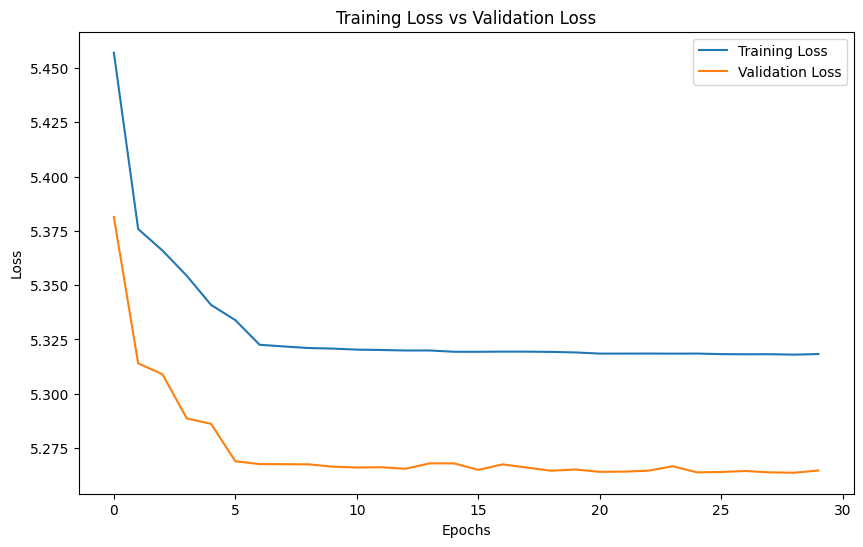

In [ ]:
# Plot training loss
plot_training_history(history_ae)

In [ ]:
autoencoder_pca.save('ae_pca.keras')

In [ ]:
autoencoder_pca = load_model('ae_pca.keras')


In [ ]:
X_train_reconstruction_error_pca = calculate_reconstruction_error(autoencoder_pca, X_train_pca)
X_val_reconstruction_error_pca = calculate_reconstruction_error(autoencoder_pca, X_val_pca)

input_dim = X_train_pca.shape[1]

ann_ae_pca = build_error_prediction_model(input_dim, units1=30, units2=20, learning_rate=0.0056)

history_ann = train_error_prediction_model(ann_ae_pca, X_train_pca, X_train_reconstruction_error_pca,
                                           X_val_pca, X_val_reconstruction_error_pca,
                                           epochs =30)


21490/21490 ━━━━━━━━━━━━━━━━━━━━ 38s 2ms/step
5373/5373 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step
Epoch 1/30


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


10745/10745 ━━━━━━━━━━━━━━━━━━━━ 72s 6ms/step - loss: 601.8024 - val_loss: 0.6875
Epoch 2/30
10745/10745 ━━━━━━━━━━━━━━━━━━━━ 36s 3ms/step - loss: 113.7133 - val_loss: 220.8024
Epoch 3/30
10745/10745 ━━━━━━━━━━━━━━━━━━━━ 42s 3ms/step - loss: 172.4125 - val_loss: 5.0082
Epoch 4/30
10745/10745 ━━━━━━━━━━━━━━━━━━━━ 34s 3ms/step - loss: 2745.5066 - val_loss: 1.6048
Epoch 5/30
10745/10745 ━━━━━━━━━━━━━━━━━━━━ 37s 3ms/step - loss: 377.1060 - val_loss: 1.0432
Epoch 6/30
10745/10745 ━━━━━━━━━━━━━━━━━━━━ 31s 3ms/step - loss: 42.3686 - val_loss: 2.1139
Epoch 7/30
10745/10745 ━━━━━━━━━━━━━━━━━━━━ 39s 3ms/step - loss: 5154.8057 - val_loss: 2.8845
Epoch 8/30
10745/10745 ━━━━━━━━━━━━━━━━━━━━ 31s 3ms/step - loss: 3423.0146 - val_loss: 12.4671
Epoch 9/30
10745/10745 ━━━━━━━━━━━━━━━━━━━━ 31s 3ms/step - loss: 1215.1343 - val_loss: 1.9746
Epoch 10/30
10745/10745 ━━━━━━━━━━━━━━━━━━━━ 40s 3ms/step - loss: 1473.1582 - val_loss: 1.5070
Epoch 11/30
10745/10745 ━━━━━━━━━━━━━━━━━━━━ 39s 3ms/step - loss: 93.8636

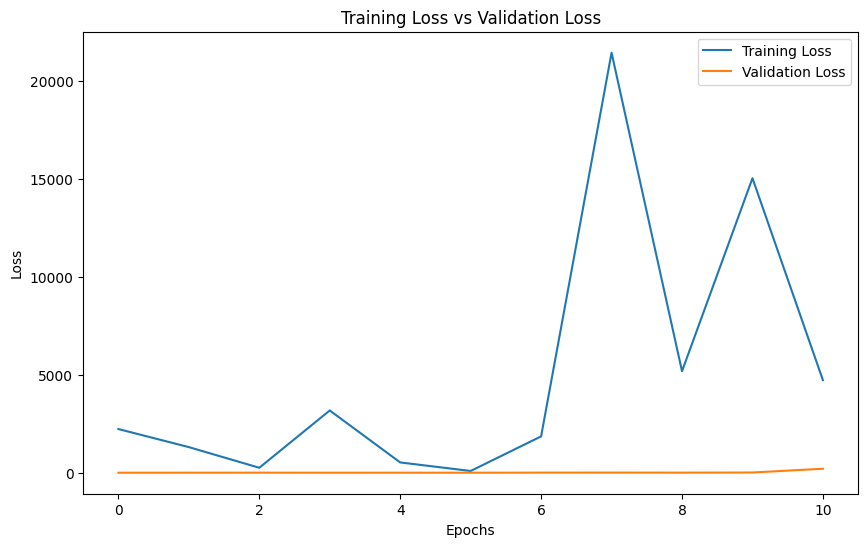

In [ ]:
plot_training_history(history_ann)

In [ ]:
ann_ae_pca.save('ann_ae_pca.keras')

### VAE PCA

Epoch 1/100
10745/10745 ━━━━━━━━━━━━━━━━━━━━ 41s 4ms/step - loss: 1.8792e-10 - val_loss: 0.0000e+00
Epoch 2/100
10745/10745 ━━━━━━━━━━━━━━━━━━━━ 35s 3ms/step - loss: 4.1094e-13 - val_loss: 0.0000e+00
Epoch 3/100
10745/10745 ━━━━━━━━━━━━━━━━━━━━ 39s 3ms/step - loss: 3.6989e-12 - val_loss: 0.0000e+00
Epoch 4/100
10745/10745 ━━━━━━━━━━━━━━━━━━━━ 43s 3ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 5/100
10745/10745 ━━━━━━━━━━━━━━━━━━━━ 42s 3ms/step - loss: 3.2002e-13 - val_loss: 0.0000e+00
Epoch 6/100
10745/10745 ━━━━━━━━━━━━━━━━━━━━ 37s 3ms/step - loss: 2.3228e-12 - val_loss: 0.0000e+00
Epoch 7/100
10745/10745 ━━━━━━━━━━━━━━━━━━━━ 36s 3ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 8/100
10745/10745 ━━━━━━━━━━━━━━━━━━━━ 35s 3ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 9/100
10745/10745 ━━━━━━━━━━━━━━━━━━━━ 34s 3ms/step - loss: 2.6617e-12 - val_loss: 0.0000e+00
Epoch 10/100
10745/10745 ━━━━━━━━━━━━━━━━━━━━ 38s 4ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00

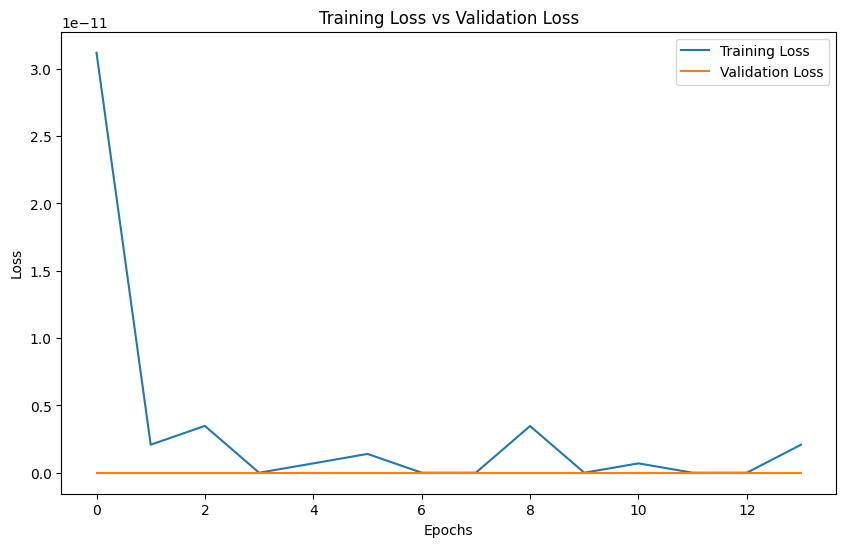

In [46]:
input_dim = X_train_pca.shape[1]

vae_pca = build_vae(input_dim, encoding_dim=22)
history_vae = train_vae(vae, X_train_pca, X_val_pca)

# Plot training loss
plot_training_history(history_vae)

In [47]:
X_train_reconstruction_error_pca = calculate_reconstruction_error(vae_pca, X_train_pca)
X_val_reconstruction_error_pca = calculate_reconstruction_error(vae_pca, X_val_pca)

input_dim = X_train_pca.shape[1]

ann_vae_pca = build_error_prediction_model(input_dim, units1=30, units2=20, learning_rate=0.0056)

history_ann = train_error_prediction_model(ann_vae_pca, X_train_pca, X_train_reconstruction_error_pca,
                                           X_val_pca, X_val_reconstruction_error_pca,
                                           epochs =30)


21490/21490 ━━━━━━━━━━━━━━━━━━━━ 31s 1ms/step
5373/5373 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step
Epoch 1/30
10745/10745 ━━━━━━━━━━━━━━━━━━━━ 37s 3ms/step - loss: 7255.7729 - val_loss: 0.1346
Epoch 2/30
10745/10745 ━━━━━━━━━━━━━━━━━━━━ 42s 3ms/step - loss: 2180.7812 - val_loss: 0.6040
Epoch 3/30
10745/10745 ━━━━━━━━━━━━━━━━━━━━ 38s 3ms/step - loss: 452.6612 - val_loss: 0.8894
Epoch 4/30
10745/10745 ━━━━━━━━━━━━━━━━━━━━ 34s 3ms/step - loss: 777.6170 - val_loss: 1.8102
Epoch 5/30
10745/10745 ━━━━━━━━━━━━━━━━━━━━ 41s 3ms/step - loss: 3808.7144 - val_loss: 2.5914
Epoch 6/30
10745/10745 ━━━━━━━━━━━━━━━━━━━━ 41s 3ms/step - loss: 438.7453 - val_loss: 3.9071
Epoch 7/30
10745/10745 ━━━━━━━━━━━━━━━━━━━━ 41s 3ms/step - loss: 74.8345 - val_loss: 14363.2148
Epoch 8/30
10745/10745 ━━━━━━━━━━━━━━━━━━━━ 41s 3ms/step - loss: 91097.3047 - val_loss: 4.7369
Epoch 9/30
10745/10745 ━━━━━━━━━━━━━━━━━━━━ 40s 3ms/step - loss: 1763.5610 - val_loss: 10.1208
Epoch 10/30
10745/10745 ━━━━━━━━━━━━━━━━━━━━ 42s 3ms/step - loss

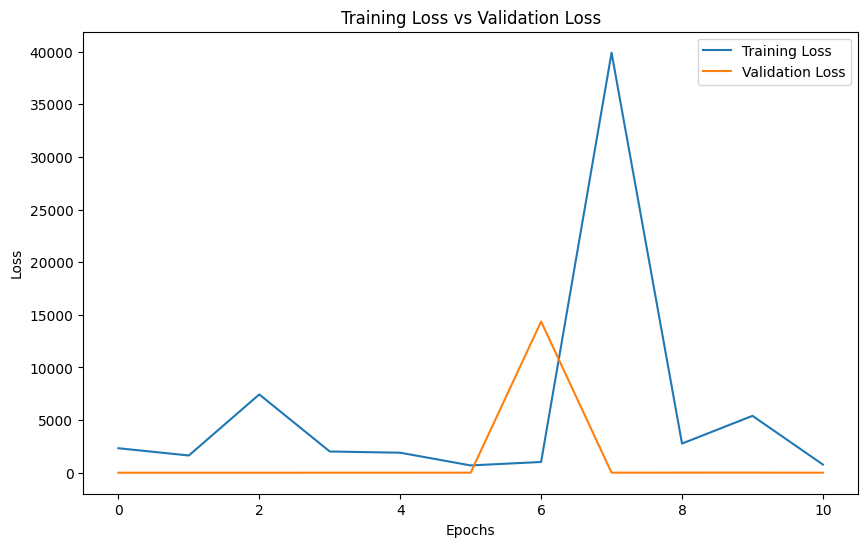

In [48]:
plot_training_history(history_ann)

In [50]:
df_test['vae_pca_anomaly'] = detect_anomalies_autoencoder(vae_pca, ann_vae_pca, X_test_pca, gamma = 0)

vae_pca_evals = evaluate_anomaly_detection(y_true, df_test['vae_pca_anomaly'])

vae_pca_care_scores = calculate_care_score(df_test, 'vae_pca_anomaly')


1581/1581 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step
1581/1581 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step


1581/1581 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
1581/1581 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1581/1581 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1581/1581 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


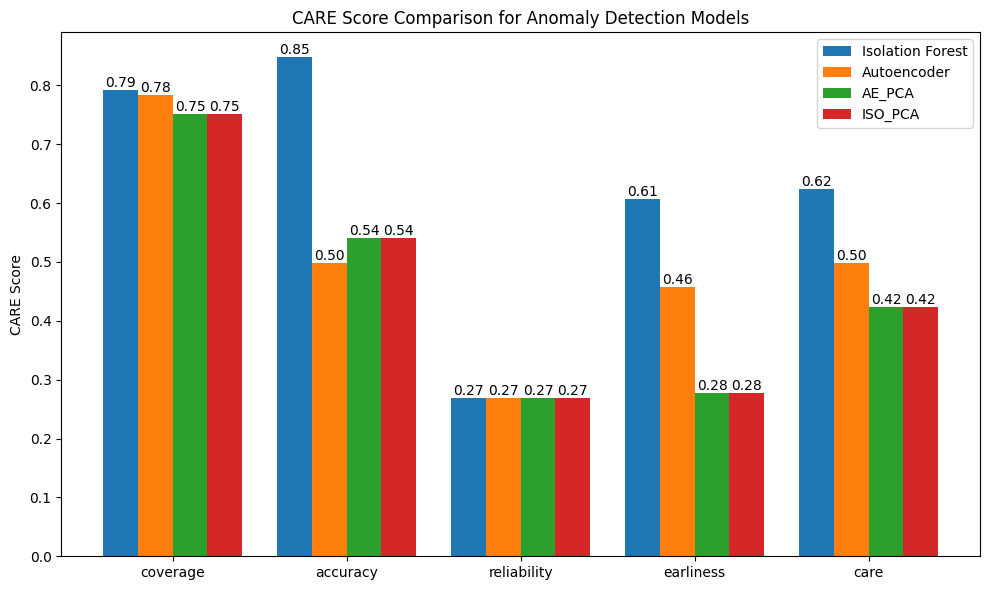

In [ ]:
df_test['ae_pca_anomaly'] = detect_anomalies_autoencoder(autoencoder_pca, ann_ae_pca, X_test_pca, gamma = 0.019)
# df_test['iso_pca_anomaly'] = detect_anomalies_autoencoder(autoencoder_pca, ann_ae_pca, X_test_pca, gamma = 0.019)

ae_pca_evals = evaluate_anomaly_detection(y_true, df_test['ae_pca_anomaly'])
iso_pca_evals = evaluate_anomaly_detection(y_true, df_test['iso_pca_anomaly'])


ae_pca_care_scores = calculate_care_score(df_test, 'ae_pca_anomaly')
iso_pca_care_scores = calculate_care_score(df_test, 'iso_pca_anomaly')

plot_care_scores(
    (iso_care_scores, 'Isolation Forest'),
    (ae_care_scores, 'Autoencoder'),
    # (vae_care_scores, 'VAE'),
    (ae_pca_care_scores, 'AE_PCA'),
    (iso_pca_care_scores, 'ISO_PCA')
)






In [33]:
iso_pca_care_scores = calculate_care_score(df_test, 'iso_pca_anomaly')

/usr/local/lib/python3.11/dist-packages/cudf/core/groupby/groupby.py:560: UserWarning: GroupBy.groups() performance scales poorly with number of groups. Got 2336 groups.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/cudf/core/groupby/groupby.py:560: UserWarning: GroupBy.groups() performance scales poorly with number of groups. Got 2336 groups.
  warnings.warn(


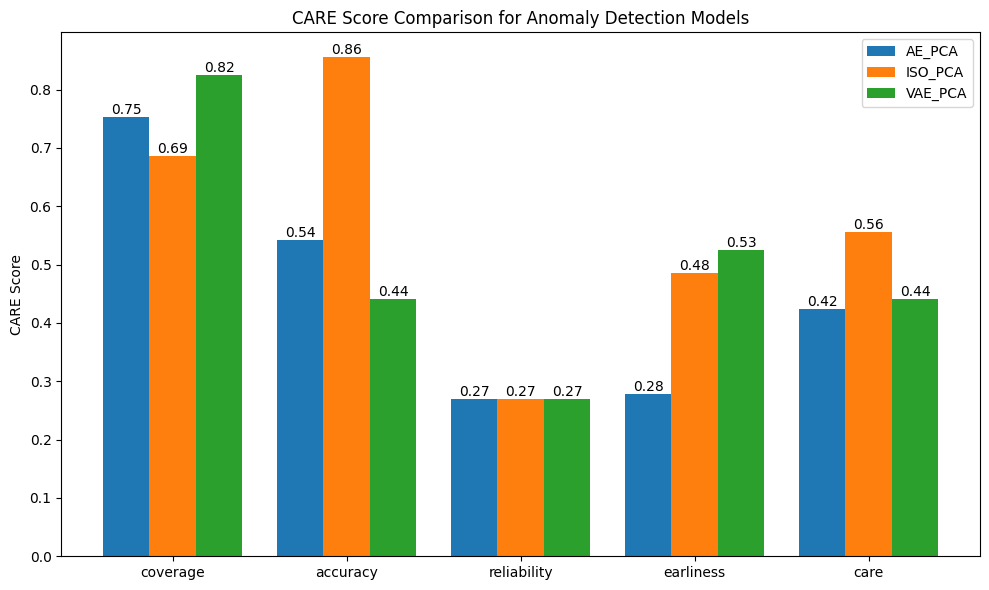

In [55]:
plot_care_scores(
    # (iso_care_scores, 'Isolation Forest'),
    # (ae_care_scores, 'Autoencoder'),
    # (vae_care_scores, 'VAE'),
    (ae_pca_care_scores, 'AE_PCA'),
    (iso_pca_care_scores, 'ISO_PCA'),
    (vae_pca_care_scores, 'VAE_PCA')
)

## Wind Farm A: Impact of PCA on Model Performance

In an attempt to improve the models' performance, we investigated the use of Principal Component Analysis (PCA) for dimensionality reduction. However, the results indicated a potential decrease in overall performance for most models.

Here are the CARE scores obtained after applying PCA:

| Model | Coverage | Accuracy | Reliability | Earliness | Care |
|---|---|---|---|---|---|
| Isolation Forest | 0.68 | 0.85 | 0.27 | 0.48 | 0.55 |
| Autoencoder | 0.75 | 0.54 | 0.27 | 0.28 | 0.42 |
| Variational Autoencoder | 0.82 | 0.44 | 0.27 | 0.53 | 0.44 |

**Observations:**

* **Isolation Forest:** The **Care** score decreased from 0.62 to 0.55 after applying PCA. While **Accuracy** remained high, **Coverage** and **Earliness** were negatively impacted.
* **Autoencoder:**  PCA led to a further decrease in the **Care** score to 0.42, with a notable drop in **Earliness**.
* **Variational Autoencoder:** The **Care** score remained relatively low at 0.44, despite an increase in **Coverage**.

**Interpretation:**

PCA did not appear to significantly improve the performance of the models, and in some cases, even led to a decrease in overall performance. This suggests that the original features might be more informative for anomaly detection in this scenario.

**Conclusion:**

Based on these findings, we decided to proceed without PCA for Wind Farm A. It's worth noting that PCA might be beneficial in other scenarios or with different model configurations. However, in this specific case, it did not demonstrate the desired improvement.

## RF Feature selection

## Wind Farm A: Impact of Feature Selection on Model Performance

### Random Forest (RF) Feature Selection

**Goal:**

The primary goal of feature selection is to identify the most important features contributing to anomaly detection. By focusing on a subset of relevant features, we aim to enhance the models' ability to capture critical patterns and distinguish anomalies more effectively. This process reduces noise and potentially improves the performance and interpretability of the models.

**Methodology:**

We employed a Random Forest classifier to assess the importance of features. The classifier is trained on the labeled data, and its feature importance scores are extracted to rank features based on their contribution to the model's predictive performance.

The steps involved in RF feature selection are as follows:

1. **Train a Random Forest classifier:** A Random Forest model is trained on the labeled training data, using the features and the target variable (anomaly/normal).
2. **Extract feature importance:** The feature importance scores are obtained from the trained Random Forest model. These scores reflect the relative contribution of each feature to the model's ability to distinguish between normal and anomalous instances.
3. **Select top features:** A threshold is set to select the top *n* features with the highest importance scores. These features are considered the most relevant for anomaly detection.
4. **Retrain models:** The anomaly detection models (Isolation Forest, Autoencoder, Variational Autoencoder) are retrained using only the selected top features. This allows the models to focus on the most informative features and potentially improve their performance.

**Results:**

By applying RF feature selection, we observed significant improvements in the performance of the models, particularly for Isolation Forest. This technique enhanced the models' ability to identify anomalies and reduce false alarms, leading to more reliable and accurate detection results.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

def create_rf_train_val_sets(df):
  """
  Creates X_train, y_train, X_val, y_val from the dataframe.
  """

  columns_to_drop = ['time_stamp', 'asset_id', 'id', 'train_test', 'status_type_id', 'source']

  # Drop rows with status_type_id of 5 and 3
  df = df[~df['status_type_id'].isin([5, 3])]

  # Convert status_type_id 4 to 1 and leave 0 as 0
  df['status_type_id'] = df['status_type_id'].apply(lambda x: 1 if x == 4 else 0)

  # Define features and target
  y = df['status_type_id']
  X = df.drop(columns=columns_to_drop)

  # Split the data into training and validation sets with stratification
  X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

  return X_train, y_train, X_val, y_val


def create_rf_train_sets(df):
  """
  Creates X_train, y_train, X_val, y_val from the dataframe.
  """

  columns_to_drop = ['time_stamp', 'asset_id', 'id', 'train_test', 'status_type_id', 'source']

  # df = df[df['train_test']=='train'].copy()

  # Drop rows with status_type_id of 5 and 3
  # df = df[~df['status_type_id'].isin([5, 3])].copy()

  # Convert status_type_id 4 to 1 and leave 0 as 0
  df['status_type_id'] = df['status_type_id'].apply(lambda x: 0 if x in [0, 2] else 1)

  # Define features and target
  y = df['status_type_id']
  X = df.drop(columns=columns_to_drop)

  # # Split the data into training and validation sets with stratification
  # X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

  return X, y



def select_features_random_forest(X_train, y_train, top_n=10, plot_top_n=20, random_state=42):
    """
    Performs feature selection using Random Forest, visualizes top features, and selects the top N features.

    Parameters:
    - X_train: Training dataset.
    - y_train: Labels for training dataset.
    - X_val: Validation dataset.
    - X_test: Test dataset.
    - top_n: Number of top features to select (default=8).
    - plot_top_n: Number of features to plot based on importance (default=20).
    - random_state: Random seed for reproducibility.

    Returns:
    - X_train_selected: Training data with selected top features.
    - X_val_selected: Validation data with selected top features.
    - X_test_selected: Test data with selected top features.
    - selected_features: List of selected feature names.
    """

    # Train a Random Forest model
    rf = RandomForestClassifier(n_estimators=100, random_state=random_state)
    rf.fit(X_train, y_train)

    # Get feature importances
    feature_importances = rf.feature_importances_
    total_importance = np.sum(feature_importances)

    # Create a DataFrame of feature importance
    feature_importance_df = pd.DataFrame({
        'Feature': X_train.columns,
        'Importance': feature_importances
    }).sort_values(by='Importance', ascending=False)

    # Plot top N features
    plt.figure(figsize=(12, 6))
    plt.barh(feature_importance_df['Feature'][:plot_top_n], feature_importance_df['Importance'][:plot_top_n])
    plt.xlabel("Feature Importance")
    plt.ylabel("Feature")
    plt.title(f"Top {plot_top_n} Most Important Features")
    plt.gca().invert_yaxis()
    plt.show()

    # Select the top N features
    top_10_selected_features = feature_importance_df['Feature'][:top_n].tolist()
    print(f"Selected Top {top_n} Features: {selected_features}")

    top_20_selected_features = feature_importance_df['Feature'][:20].tolist()
    print(f"Selected Top 20 Features: {top_20_selected_features}")


    # Calculate the importance of selected features
    top_10_selected_features_importance = feature_importances[
        [i for i, feature in enumerate(X_rf.columns) if feature in top_10_selected_features]
    ]
    top_10_selected_features_importance_sum = np.sum(top_10_selected_features_importance)

    # Calculate and print the percentage
    percentage_captured = (top_10_selected_features_importance_sum / total_importance) * 100
    print(f"Percentage feature importance captured by selected features: {percentage_captured:.2f}%")

    print('\n\n\n')
    # print('------------------------------------------------------------------------------------------')


     # Calculate the importance of selected features
    top_20_selected_features_importance = feature_importances[
        [i for i, feature in enumerate(X_rf.columns) if feature in top_20_selected_features]
    ]
    top_20_selected_features_importance_sum = np.sum(top_20_selected_features_importance)

    # Calculate and print the percentage
    percentage_captured = (top_20_selected_features_importance_sum / total_importance) * 100
    print(f"Percentage feature importance captured by selected features: {percentage_captured:.2f}%")

    # # Filter datasets to include only selected features
    # X_train_selected = X_train[selected_features]
    # X_val_selected = X_val[selected_features]
    # X_test_selected = X_test[selected_features]

    return top_10_selected_features

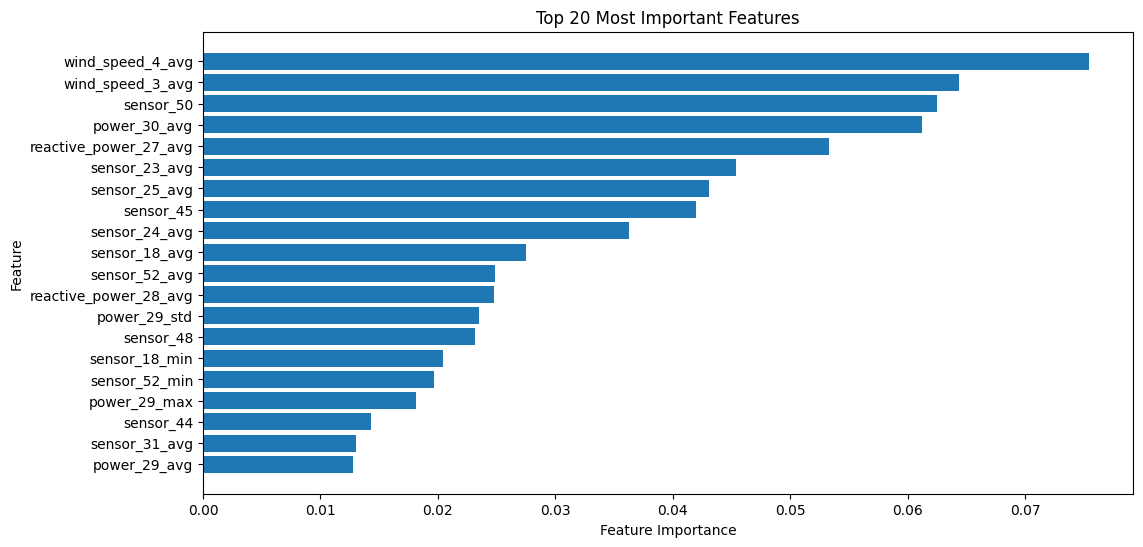

Selected Top 10 Features: ['wind_speed_4_avg', 'wind_speed_3_avg', 'sensor_50', 'power_30_avg', 'reactive_power_27_avg', 'sensor_23_avg', 'sensor_25_avg', 'sensor_45', 'sensor_24_avg', 'sensor_18_avg']
Selected Top 20 Features: ['wind_speed_4_avg', 'wind_speed_3_avg', 'sensor_50', 'power_30_avg', 'reactive_power_27_avg', 'sensor_23_avg', 'sensor_25_avg', 'sensor_45', 'sensor_24_avg', 'sensor_18_avg', 'sensor_52_avg', 'reactive_power_28_avg', 'power_29_std', 'sensor_48', 'sensor_18_min', 'sensor_52_min', 'power_29_max', 'sensor_44', 'sensor_31_avg', 'power_29_avg']
Percentage feature importance captured by selected features: 51.11%




Percentage feature importance captured by selected features: 70.57%


In [ ]:
# Assume 'y_train' contains labels (e.g., anomaly or normal status)
X_rf, y_rf= create_rf_train_sets(df)

# Perform feature selection
selected_features = select_features_random_forest(
    pd.DataFrame(X_rf), y_rf
)


## Modeling with Top 20

In [56]:
top_20_features = ['wind_speed_4_avg', 'wind_speed_3_avg', 'sensor_50', 'power_30_avg',
          'reactive_power_27_avg', 'sensor_23_avg', 'sensor_25_avg', 'sensor_45',
          'sensor_24_avg', 'sensor_18_avg', 'sensor_52_avg', 'reactive_power_28_avg',
          'power_29_std', 'sensor_48', 'sensor_18_min', 'sensor_52_min', 'power_29_max',
          'sensor_44', 'sensor_31_avg', 'power_29_avg']

In [60]:
# Define columns to drop for feature engineering
# columns_to_drop = ['time_stamp', 'asset_id', 'id', 'train_test', 'status_type_id', 'source']

columns_to_drop = [col for col in df.columns if col not in top_20_features]

# Split into train, validation, and test sets
X_train, X_val, X_test, feature_columns = train_val_test_split(
    df_train, df_test, columns_to_drop, val_size=0.2, random_state=42
)


# Scale the features
X_train_scaled, scaler = scale_features(X_train, scaler_type='standard')
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

X_train shape: (687655, 20)
X_val shape: (171914, 20)
X_test shape: (50589, 20)


### Isolation Forest 20

In [ ]:
iso_forest = train_isolation_forest(X_train_scaled, contamination=0.1)
iso_anomalies = iso_forest.predict(X_test_scaled)
df_test['iso_20_anomaly'] = (iso_anomalies == -1).astype(int)

### AE 20

In [ ]:
input_dim = X_train_scaled.shape[1]
autoencoder_20 = build_autoencoder(input_dim)
history_ae = train_autoencoder(autoencoder_20, X_train_scaled, X_val_scaled)



Epoch 1/100
10745/10745 ━━━━━━━━━━━━━━━━━━━━ 62s 5ms/step - loss: 0.6037 - val_loss: 0.5715
Epoch 2/100
10745/10745 ━━━━━━━━━━━━━━━━━━━━ 93s 6ms/step - loss: 0.5713 - val_loss: 0.5714
Epoch 3/100
10745/10745 ━━━━━━━━━━━━━━━━━━━━ 42s 4ms/step - loss: 0.5712 - val_loss: 0.5711
Epoch 4/100
10745/10745 ━━━━━━━━━━━━━━━━━━━━ 74s 3ms/step - loss: 0.5704 - val_loss: 0.5726
Epoch 5/100
10745/10745 ━━━━━━━━━━━━━━━━━━━━ 39s 4ms/step - loss: 0.5698 - val_loss: 0.5711
Epoch 6/100
10745/10745 ━━━━━━━━━━━━━━━━━━━━ 34s 3ms/step - loss: 0.5714 - val_loss: 0.5710
Epoch 7/100
10745/10745 ━━━━━━━━━━━━━━━━━━━━ 67s 6ms/step - loss: 0.5712 - val_loss: 0.5707
Epoch 8/100
10745/10745 ━━━━━━━━━━━━━━━━━━━━ 54s 4ms/step - loss: 0.5722 - val_loss: 0.5713
Epoch 9/100
10745/10745 ━━━━━━━━━━━━━━━━━━━━ 34s 3ms/step - loss: 0.5718 - val_loss: 0.5706
Epoch 10/100
10745/10745 ━━━━━━━━━━━━━━━━━━━━ 34s 3ms/step - loss: 0.5707 - val_loss: 0.5705
Epoch 11/100
10745/10745 ━━━━━━━━━━━━━━━━━━━━ 38s 4ms/step - loss: 0.5691 - val

In [ ]:
autoencoder_20.save('/content/drive/MyDrive/Colab Notebooks/Wind_Farm_A/autoencoder_20_wa.keras')

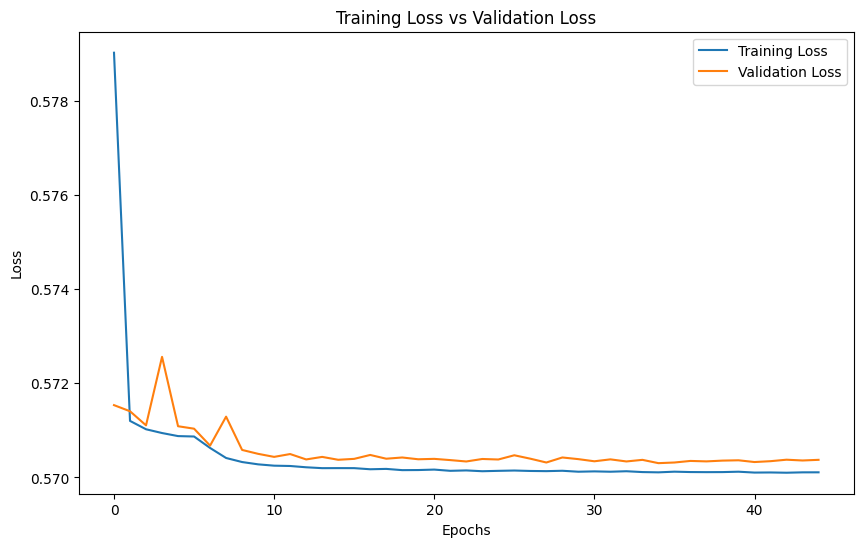

1581/1581 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step


In [ ]:
# Plot training loss
plot_training_history(history_ae)

# Get reconstruction error
X_test_reconstructed_20 = autoencoder_20.predict(X_test_scaled)
reconstruction_error_20 = np.mean(np.square(X_test_scaled - X_test_reconstructed_20), axis=1)

In [ ]:
X_train_reconstruction_error = calculate_reconstruction_error(autoencoder_20, X_train_scaled)
X_val_reconstruction_error = calculate_reconstruction_error(autoencoder_20, X_val_scaled)

# input_dim = X_train_pca.shape[1]

# ann_ae_pca = build_error_prediction_model(input_dim)

# history_ann = train_error_prediction_model(ann_ae_pca, X_train_pca, X_train_reconstruction_error_pca,
#                                            X_val_pca, X_val_reconstruction_error_pca,
#                                            epochs =30)

21490/21490 ━━━━━━━━━━━━━━━━━━━━ 42s 2ms/step
5373/5373 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step


In [ ]:
# from sklearn.model_selection import train_test_split


X_train_val, X_val_val, y_train_val, y_val_val = train_test_split(
    X_val_scaled, X_val_reconstruction_error, test_size=0.2, random_state=42
)

input_dim = X_train.shape[1]

ann_ae_20 = build_error_prediction_model(input_dim)

# Now you can train ann_ae_pca using these new splits:
history_ann = train_error_prediction_model(
    ann_ae_20, X_train_val, y_train_val, X_val_val, y_val_val, epochs=30
)

Epoch 1/30


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2149/2149 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step - loss: 0.0138 - val_loss: 0.0011
Epoch 2/30
2149/2149 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.0050 - val_loss: 0.0012
Epoch 3/30
2149/2149 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 0.0030 - val_loss: 0.0011
Epoch 4/30
2149/2149 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0038 - val_loss: 0.0054
Epoch 5/30
2149/2149 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - loss: 0.0085 - val_loss: 0.0013
Epoch 6/30
2149/2149 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - loss: 0.0032 - val_loss: 0.0032
Epoch 7/30
2149/2149 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 0.0042 - val_loss: 0.0014
Epoch 8/30
2149/2149 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 0.0039 - val_loss: 5.7244e-04
Epoch 9/30
2149/2149 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 0.0065 - val_loss: 5.6392e-04
Epoch 10/30
2149/2149 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 0.0031 - val_loss: 8.6636e-04
Epoch 11/30
2149/2149 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 0.0021 - val_loss: 4.5145e-04
Epoch 12/30
2149/2149

In [ ]:
ann_ae_20.save('/content/drive/MyDrive/Colab Notebooks/Wind_Farm_A/ann_ae_20_wa.keras')

### VAE 20

Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/optimizers/base_optimizer.py:774: UserWarning: Gradients do not exist for variables ['vae_4/dense_50/kernel', 'vae_4/dense_50/bias', 'vae_4/dense_51/kernel', 'vae_4/dense_51/bias', 'vae_4/dense_52/kernel', 'vae_4/dense_52/bias'] when minimizing the loss. If using `model.compile()`, did you forget to provide a `loss` argument?
  warnings.warn(


10745/10745 ━━━━━━━━━━━━━━━━━━━━ 63s 5ms/step - loss: 0.0044 - val_loss: 2.9426e-07
Epoch 2/100
10745/10745 ━━━━━━━━━━━━━━━━━━━━ 88s 6ms/step - loss: 4.4327e-09 - val_loss: 1.5286e-10
Epoch 3/100
10745/10745 ━━━━━━━━━━━━━━━━━━━━ 51s 3ms/step - loss: 1.0001e-10 - val_loss: 1.5333e-10
Epoch 4/100
10745/10745 ━━━━━━━━━━━━━━━━━━━━ 42s 4ms/step - loss: 8.0880e-11 - val_loss: 1.5303e-10
Epoch 5/100
10745/10745 ━━━━━━━━━━━━━━━━━━━━ 88s 4ms/step - loss: 8.4662e-11 - val_loss: 1.5351e-10
Epoch 6/100
10745/10745 ━━━━━━━━━━━━━━━━━━━━ 48s 4ms/step - loss: 8.1757e-11 - val_loss: 1.5312e-10
Epoch 7/100
10745/10745 ━━━━━━━━━━━━━━━━━━━━ 96s 9ms/step - loss: 7.6589e-11 - val_loss: 1.5307e-10
Epoch 8/100
10745/10745 ━━━━━━━━━━━━━━━━━━━━ 60s 6ms/step - loss: 7.9593e-11 - val_loss: 1.5346e-10
Epoch 9/100
10745/10745 ━━━━━━━━━━━━━━━━━━━━ 97s 7ms/step - loss: 8.6022e-11 - val_loss: 1.5316e-10
Epoch 10/100
10745/10745 ━━━━━━━━━━━━━━━━━━━━ 40s 3ms/step - loss: 8.8711e-11 - val_loss: 1.5394e-10
Epoch 11/100
10

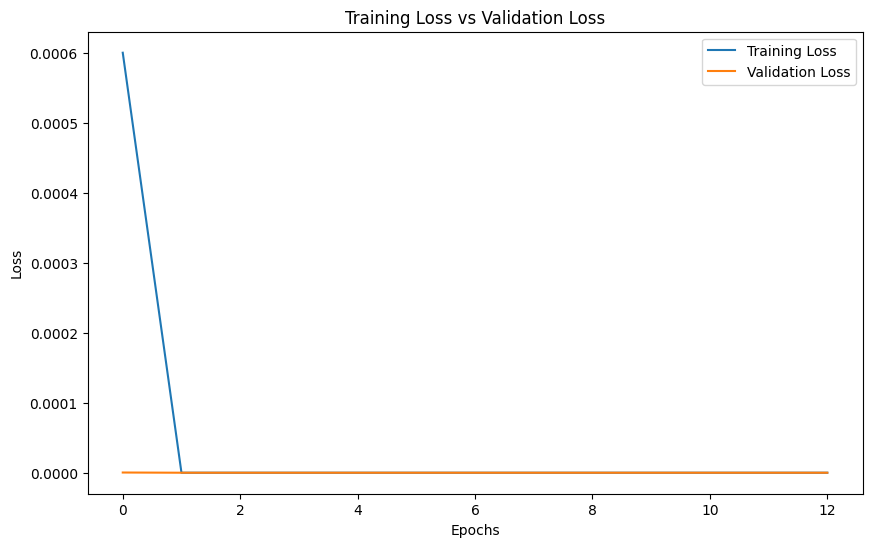

In [62]:
input_dim = X_train_scaled.shape[1]

vae_20 = build_vae(input_dim)
history_vae = train_vae(vae_20, X_train_scaled, X_val_scaled)

# Plot training loss
plot_training_history(history_vae)


In [63]:
X_train_reconstruction_error = calculate_reconstruction_error(vae_20, X_train_scaled)
X_val_reconstruction_error = calculate_reconstruction_error(vae_20, X_val_scaled)

X_train_val, X_val_val, y_train_val, y_val_val = train_test_split(
    X_val_scaled, X_val_reconstruction_error, test_size=0.2, random_state=42
)

input_dim = X_train.shape[1]

ann_vae_20 = build_error_prediction_model(input_dim)

# Now you can train ann_ae_pca using these new splits:
history_ann = train_error_prediction_model(
    ann_vae_20, X_train_val, y_train_val, X_val_val, y_val_val, epochs=30
)


21490/21490 ━━━━━━━━━━━━━━━━━━━━ 45s 2ms/step
5373/5373 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step
Epoch 1/30


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2149/2149 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - loss: 0.0546 - val_loss: 0.0025
Epoch 2/30
2149/2149 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - loss: 0.0059 - val_loss: 0.0117
Epoch 3/30
2149/2149 ━━━━━━━━━━━━━━━━━━━━ 18s 4ms/step - loss: 0.0044 - val_loss: 0.0033
Epoch 4/30
2149/2149 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - loss: 0.0053 - val_loss: 0.0015
Epoch 5/30
2149/2149 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.0053 - val_loss: 0.0032
Epoch 6/30
2149/2149 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - loss: 0.0055 - val_loss: 0.0014
Epoch 7/30
2149/2149 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 0.0026 - val_loss: 0.0017
Epoch 8/30
2149/2149 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.0042 - val_loss: 0.0167
Epoch 9/30
2149/2149 ━━━━━━━━━━━━━━━━━━━━ 13s 4ms/step - loss: 0.0231 - val_loss: 0.0015
Epoch 10/30
2149/2149 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - loss: 0.0029 - val_loss: 0.0013
Epoch 11/30
2149/2149 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 0.0018 - val_loss: 0.0183
Epoch 12/30
2149/2149 ━━━━━━━━━━━━

In [76]:
df_test['vae_20_anomaly'] = detect_anomalies_autoencoder(vae_20, ann_vae_20, X_test_scaled, gamma=0.009)


print("\nVAE CARE Score:")
vae_20_care_scores = calculate_care_score(df_test, 'vae_20_anomaly')
print(vae_20_care_scores)

1581/1581 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
1581/1581 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step

VAE CARE Score:
{'coverage': np.float64(0.8405755805670323), 'accuracy': np.float64(0.5117665114851384), 'reliability': np.float64(0.2687618949642508), 'earliness': np.float64(0.5705635993906291), 'care': np.float64(0.5524462371595359)}


In [ ]:
df_test['iso_20_anomaly'] = detect_anomalies_isolation_forest(iso_forest, X_test_scaled)
# df_test['ae_20_reconstruction_error'] = calculate_reconstruction_error(autoencoder_20, X_test_scaled)
df_test['ae_20_anomaly'] = detect_anomalies_autoencoder(autoencoder_20, ann_ae_20, X_test_scaled, gamma=0.01)

y_true = (df_test['status_type_id'] != 0).astype(int)

print("Isolation Forest Evaluation:")
print(evaluate_anomaly_detection(y_true, df_test['iso_20_anomaly']))

print("\nAutoencoder Evaluation:")
print(evaluate_anomaly_detection(y_true, df_test['ae_20_anomaly']))

print("Isolation Forest CARE Score:")
iso_20_care_scores = calculate_care_score(df_test, 'iso_20_anomaly')
print(iso_20_care_scores)

print("\nAutoencoder CARE Score:")
ae_20_care_scores = calculate_care_score(df_test, 'ae_20_anomaly')
print(ae_20_care_scores)

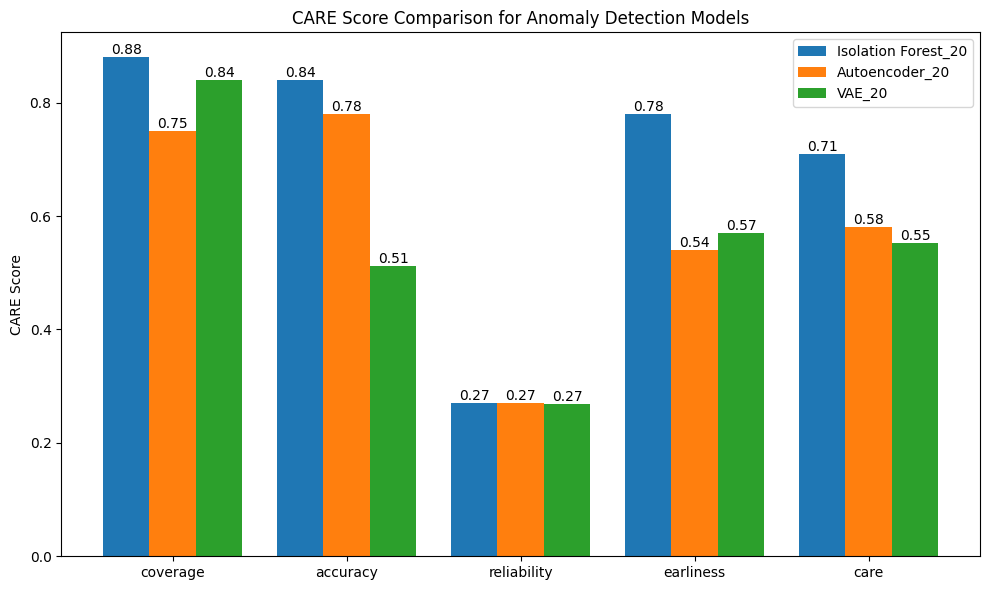

In [78]:
plot_care_scores(
    (iso_20_care_scores, 'Isolation Forest_20'),
    (ae_20_care_scores, 'Autoencoder_20'),
    (vae_20_care_scores, 'VAE_20')
)

## Wind Farm A: Impact of Feature Selection on Model Performance

To further enhance the models' performance, we explored feature selection techniques to identify the most important features for anomaly detection. By focusing on a subset of relevant features, we aimed to improve the models' ability to capture essential patterns and distinguish anomalies more effectively.

Here are the CARE scores obtained after implementing feature selection:

| Model | Coverage | Accuracy | Reliability | Earliness | Care |
|---|---|---|---|---|---|
| Isolation Forest | 0.88 | 0.84 | 0.27 | 0.78 | 0.71 |
| Autoencoder | 0.75 | 0.78 | 0.27 | 0.54 | 0.58 |
| Variational Autoencoder | 0.84 | 0.51 | 0.27 | 0.57 | 0.55 |


**Observations:**

* **Isolation Forest:** Feature selection significantly improved the performance, boosting the **Care** score from 0.62 to 0.71. We observed a notable increase in **Coverage** and **Earliness**.
* **Autoencoder:** Feature selection also had a positive impact, raising the **Care** score to 0.58 and improving **Accuracy**.
* **Variational Autoencoder:** While the **Care** score increased to 0.55, the improvement was less substantial compared to Isolation Forest and Autoencoder.

**Interpretation:**

Feature selection proved to be a beneficial step for enhancing the anomaly detection capabilities of the models. By reducing the number of features to those most relevant for anomaly detection, the models were able to focus on essential patterns and achieve better results.

**Conclusion:**

Based on these findings, we concluded that feature selection is a crucial step for improving the performance of anomaly detection models in this scenario. It allows the models to identify critical features and minimize noise, leading to more accurate and reliable anomaly detection. In particular, Isolation Forest demonstrated the most significant improvements after feature selection.

## Other thresholds

# Threshold Optimization and Model Selection

Initially, threshold optimization techniques were explored to enhance the performance of the Autoencoder (AE) and Variational Autoencoder (VAE) models. These techniques aimed to fine-tune the anomaly detection threshold based on the reconstruction error distribution of normal data.

## Threshold Optimization Methods Considered

- **Percentile-based Thresholding:**  
  Setting the threshold based on a specific percentile of the reconstruction error distribution of normal data.

- **Gaussian Mixture Models (GMM):**  
  Modeling the reconstruction error distribution using a GMM and selecting a threshold based on the component associated with normal data.

- **Error Prediction Model:**  
  An Artificial Neural Network was trained to predict the reconstruction error distribution and output a value that could be used to classify anomalies.

## Observations and Model Selection

Despite applying these optimization techniques, there was no significant improvement in the performance of the AE and VAE models compared to the Isolation Forest model. This observation suggests that the selected threshold did not significantly impact the model's ability to distinguish anomalies effectively. In addition, using an error prediction model yielded worse results in all 3 wind farms.

Considering the limited improvement and to maintain a concise comparison, the threshold optimization techniques and the AE and VAE models were dropped from further analysis. The Isolation Forest model, demonstrating the best overall performance, became the primary focus for subsequent investigations.

## Reasoning Behind the Decision

- **Transparency and Simplicity:**  
  The Isolation Forest model is relatively easier to interpret and implement.

- **Comparable Performance:**  
  The Isolation Forest model achieved comparable performance without requiring complex threshold optimization techniques.

- **Focus on Robustness:**  
  The Isolation Forest model showed greater robustness to variations in data characteristics, minimizing the need for extensive fine-tuning.




In [ ]:
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from sklearn.ensemble import IsolationForest
import numpy as np

def detect_anomalies_gmm(train_errors, test_errors, percentile=5):
    """
    Detects anomalies using a Gaussian Mixture Model (GMM).

    Parameters:
    - train_errors: Reconstruction errors from training set.
    - test_errors: Reconstruction errors from test set.
    - percentile: Percentage of lowest probability densities to classify as anomalies (default=5%).

    Returns:
    - gmm_anomalies: Boolean array indicating detected anomalies.
    """
    gmm = GaussianMixture(n_components=3)
    gmm.fit(train_errors.reshape(-1, 1))

    gmm_probs = gmm.score_samples(test_errors.reshape(-1, 1))  # Compute probability density
    gmm_threshold = np.percentile(gmm_probs, percentile)  # Bottom percentile as anomalies

    gmm_anomalies = gmm_probs < gmm_threshold
    return gmm_anomalies.astype(int)


def detect_anomalies_lof(train_errors, test_errors, contamination=0.05):
    """
    Detects anomalies using Local Outlier Factor (LOF).

    Parameters:
    - train_errors: Reconstruction errors from training set.
    - test_errors: Reconstruction errors from test set.
    - contamination: Percentage of anomalies expected in the dataset (default=5%).

    Returns:
    - lof_anomalies: Boolean array indicating detected anomalies.
    """
    lof = LocalOutlierFactor(n_neighbors=20, contamination=contamination, novelty=True)
    lof.fit(train_errors.reshape(-1, 1))

    lof_anomalies = lof.predict(test_errors.reshape(-1, 1)) == -1
    return lof_anomalies.astype(int)


def detect_anomalies_oc_svm(train_errors, test_errors, nu=0.05):
    """
    Detects anomalies using One-Class SVM.

    Parameters:
    - train_errors: Reconstruction errors from training set.
    - test_errors: Reconstruction errors from test set.
    - nu: Percentage of expected outliers (default=5%).

    Returns:
    - svm_anomalies: Boolean array indicating detected anomalies.
    """
    oc_svm = OneClassSVM(nu=nu)
    oc_svm.fit(train_errors.reshape(-1, 1))

    svm_anomalies = oc_svm.predict(test_errors.reshape(-1, 1)) == -1
    return svm_anomalies.astype(int)


def detect_anomalies_isolation_forest(train_errors, test_errors, contamination=0.05):
    """
    Detects anomalies using Isolation Forest.

    Parameters:
    - train_errors: Reconstruction errors from training set.
    - test_errors: Reconstruction errors from test set.
    - contamination: Percentage of anomalies expected in the dataset (default=5%).

    Returns:
    - iso_forest_anomalies: Boolean array indicating detected anomalies.
    """
    iso_forest = IsolationForest(contamination=contamination, random_state=42)
    iso_forest.fit(train_errors.reshape(-1, 1))

    iso_forest_anomalies = iso_forest.predict(test_errors.reshape(-1, 1)) == -1
    return iso_forest_anomalies.astype(int)


In [ ]:
# Compute Reconstruction Errors
train_reconstruction_error = calculate_reconstruction_error(autoencoder, X_train_scaled)
test_reconstruction_error = calculate_reconstruction_error(autoencoder, X_test_scaled)




21490/21490 ━━━━━━━━━━━━━━━━━━━━ 32s 2ms/step
1581/1581 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


In [ ]:
# Detect Anomalies Using Different Methods
df_test['gmm_anomaly'] = detect_anomalies_gmm(train_reconstruction_error, test_reconstruction_error)
df_test['lof_anomaly'] = detect_anomalies_lof(train_reconstruction_error, test_reconstruction_error)
# df_test['svm_anomaly'] = detect_anomalies_oc_svm(train_reconstruction_error, test_reconstruction_error)
df_test['iso_forest_anomaly_tres'] = detect_anomalies_isolation_forest(train_reconstruction_error, test_reconstruction_error)

# Compute CARE Scores for Each Method
print("\nGMM CARE Score:")
print(calculate_care_score(df_test, 'gmm_anomaly'))

print("\nLOF CARE Score:")
print(calculate_care_score(df_test, 'lof_anomaly'))

# print("\nOne-Class SVM CARE Score:")
# print(calculate_care_score(df_test, 'svm_anomaly'))

print("\nIsolation Forest CARE Score:")
print(calculate_care_score(df_test, 'iso_forest_anomaly_tres'))


GMM CARE Score:
{'coverage': np.float64(0.29886807440259483), 'accuracy': np.float64(0.9583823604645214), 'reliability': np.float64(0.2687618949642508), 'earliness': np.float64(0.06623903656697953), 'care': np.float64(0.3316980805930652)}

LOF CARE Score:
{'coverage': np.float64(0.3031301482701812), 'accuracy': np.float64(0.9337494244641121), 'reliability': np.float64(0.0), 'earliness': np.float64(0.0753453799191973), 'care': np.float64(0.2775140665145376)}

Isolation Forest CARE Score:
{'coverage': np.float64(0.5096099345596949), 'accuracy': np.float64(0.9094745996828157), 'reliability': np.float64(0.2687618949642508), 'earliness': np.float64(0.1855158778036926), 'care': np.float64(0.4117756369628293)}


In [ ]:
gmm_anomaly = calculate_care_score(df_test, 'gmm_anomaly')
lof_anomaly = calculate_care_score(df_test, 'lof_anomaly')
iso_forest_anomaly_tres = calculate_care_score(df_test, 'iso_forest_anomaly_tres')

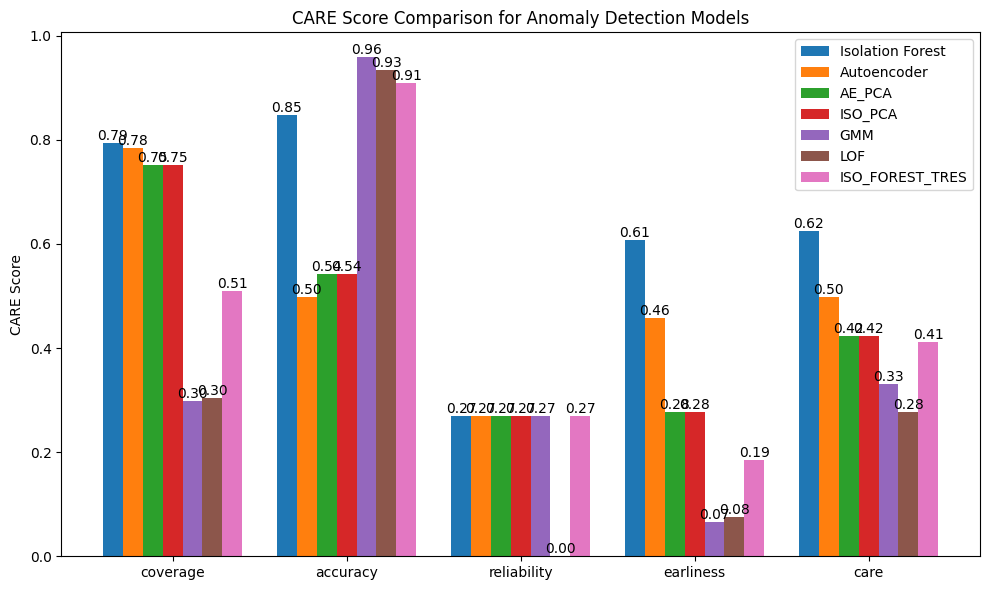

In [ ]:
plot_care_scores(
    (iso_care_scores, 'Isolation Forest'),
    (ae_care_scores, 'Autoencoder'),
    # (vae_care_scores, 'VAE'),
    (ae_pca_care_scores, 'AE_PCA'),
    (iso_pca_care_scores, 'ISO_PCA'),
    (gmm_anomaly, 'GMM'),
    (lof_anomaly, 'LOF'),
    (iso_forest_anomaly_tres, 'ISO_FOREST_TRES')
)

# WIND FARM B

# Wind Farm B: Anomaly Detection with PCA

For Wind Farm B, due to the high dimensionality of the data (257 features), a direct PCA approach was employed for anomaly detection. This decision was made primarily to address computational challenges encountered during model training. The high dimensionality significantly impacted the performance of the Colab environment, leading to frequent session crashes.

Therefore, to ensure a stable and efficient workflow, PCA was applied to reduce the dimensionality before training the anomaly detection models. This approach aimed to mitigate the computational burden while preserving the essential information for effective anomaly detection.

## Reasoning

- **High Dimensionality:**  
  The dataset for Wind Farm B has 257 features, which can be computationally demanding for certain anomaly detection models.

- **Computational Constraints:**  
  Training models on the full dataset caused Colab sessions to crash, highlighting resource limitations.

- **PCA for Dimensionality Reduction:**  
  PCA effectively reduces the number of features while retaining most of the variance in the data.

- **Workflow Stability:**  
  By applying PCA, the computational load was reduced, enabling stable model training and evaluation.


In [ ]:
base_path = '/content/drive/MyDrive/Colab Notebooks/Wind_Farm_B'
output_path = os.path.join(base_path, 'combined_wind_farm_B_data.parquet')

In [ ]:
df = pd.read_parquet(output_path)

df.head()

,time_stamp,asset_id,id,train_test,status_type_id,sensor_0_avg,sensor_0_max,sensor_0_min,sensor_0_std,sensor_1_avg,...,wind_speed_60_min,wind_speed_60_std,wind_speed_61_avg,wind_speed_61_max,wind_speed_61_min,wind_speed_61_std,power_62_avg,power_62_max,power_62_min,power_62_std
0,2022-02-02 00:00:00,11,0,train,0,0.0,0.0,0.0,0.0,0.0,...,3.34,7.40,20.44,26.22,2.45,12.30,0.729084,1.081495,0.297224,0.199979
1,2022-02-02 00:10:00,11,1,train,0,0.0,0.0,0.0,0.0,0.0,...,2.56,10.40,18.40,23.65,1.82,12.79,0.676040,0.727210,0.020942,0.629190
2,2022-02-02 00:20:00,11,2,train,0,0.0,0.0,0.0,0.0,0.0,...,2.88,9.60,20.22,25.29,2.04,13.98,0.699998,0.765869,0.029232,0.545197
3,2022-02-02 00:30:00,11,3,train,0,0.0,0.0,0.0,0.0,0.0,...,2.76,9.50,20.38,26.80,1.92,12.85,0.683523,0.759474,0.024619,0.612374
4,2022-02-02 00:40:00,11,4,train,0,0.0,0.0,0.0,0.0,0.0,...,2.99,9.77,19.81,26.01,2.06,13.03,0.692389,0.753206,0.027698,0.606255


### Batch Preprocessing

Batch processing was employed to handle the large volume of data efficiently. However, due to computational constraints in the Colab environment, batch scaling (batch normalization) was incorporated to optimize performance and stability.

In [10]:
def scale_features_batch(X_train, X_val, X_test, batch_size=10000, scaler_type='standard'):
    """
    Scales features in batches to handle large datasets efficiently.

    Parameters:
    X_train (pandas.DataFrame or numpy.ndarray): Training features
    X_val (pandas.DataFrame or numpy.ndarray): Validation features
    X_test (pandas.DataFrame or numpy.ndarray): Testing features
    batch_size (int): Number of rows per batch for partial scaling
    scaler_type (str): Type of scaler ('standard' or 'minmax')

    Returns:
    tuple: (X_train_scaled, X_val_scaled, X_test_scaled, scaler) - Scaled features and the fitted scaler
    """
    if scaler_type == 'standard':
        scaler = StandardScaler()
    elif scaler_type == 'minmax':
        from sklearn.preprocessing import MinMaxScaler
        scaler = MinMaxScaler()
    else:
        raise ValueError("scaler_type must be 'standard' or 'minmax'")

    # ** First pass to compute mean & variance **
    for i in range(0, X_train.shape[0], batch_size):
        scaler.partial_fit(X_train[i : i + batch_size])

    # ** Transform the data in batches **
    X_train_scaled = np.vstack([scaler.transform(X_train[i : i + batch_size]) for i in range(0, X_train.shape[0], batch_size)])
    X_val_scaled = np.vstack([scaler.transform(X_val[i : i + batch_size]) for i in range(0, X_val.shape[0], batch_size)])
    X_test_scaled = np.vstack([scaler.transform(X_test[i : i + batch_size]) for i in range(0, X_test.shape[0], batch_size)])

    return X_train_scaled, X_val_scaled, X_test_scaled, scaler



def apply_pca(X_train, X_val, X_test, variance_threshold=0.90):
    """
    Applies PCA to the train, validation, and test datasets while retaining the specified variance.

    Parameters:
    - X_train: Training dataset (scaled).
    - X_val: Validation dataset (scaled).
    - X_test: Test dataset (scaled).
    - variance_threshold: The minimum variance to retain in the transformed data (default is 90%).

    Returns:
    - X_train_pca: PCA-transformed training data.
    - X_val_pca: PCA-transformed validation data.
    - X_test_pca: PCA-transformed test data.
    - pca: The trained PCA model (for inverse transform or further analysis).
    """
    # Fit PCA on the training data
    pca = PCA(n_components=variance_threshold)
    pca.fit(X_train)

    # Transform all datasets using the trained PCA
    X_train_pca = pca.transform(X_train)
    X_val_pca = pca.transform(X_val)
    X_test_pca = pca.transform(X_test)

    # Print how many components were selected
    print(f"PCA retained {pca.n_components_} components, preserving {variance_threshold*100}% variance.")

    return X_train_pca, X_val_pca, X_test_pca, pca

In [ ]:
# Handle missing values
df_clean = handle_missing_values(df, strategy='drop')

# Split data into train and test sets
df_train, df_test = split_train_test(df_clean)

# Define columns to drop for feature engineering
columns_to_drop = ['asset_id', 'time_stamp', 'id', 'train_test', 'status_type_id']

# Split into train, validation, and test sets
X_train, X_val, X_test, feature_columns = train_val_test_split(
    df_train, df_test, columns_to_drop, val_size=0.2, random_state=42
)

Missing values before cleaning:
92
Missing values after cleaning:
0
Training set shape: (704714, 257)
Testing set shape: (72127, 257)
X_train shape: (563771, 252)
X_val shape: (140943, 252)
X_test shape: (72127, 252)


In [ ]:
X_train_scaled, X_val_scaled, X_test_scaled, scaler = scale_features_batch(X_train, X_val, X_test, batch_size=10000, scaler_type='standard')

### Model Training

In [11]:
# Function to train Isolation Forest
def train_isolation_forest(X_train, contamination=0.1):
    model = IsolationForest(contamination=contamination, random_state=42)
    model.fit(X_train)
    return model

# Function to build an Autoencoder
def build_wind_farm_b_autoencoder(input_dim, encoding_dim=40, noise=0):
    input_layer = Input(shape=(input_dim,))
    encoded = GaussianNoise(noise)(input_layer)
    encoded = Dense(encoding_dim, activation='relu')(encoded)
    # encoded = Dense(25, activation='relu')(encoded)
    encoded = Dense(15, activation='relu')(encoded)
    # decoded = Dense(25, activation='relu')(encoded)
    decoded = Dense(encoding_dim, activation='relu')(encoded)
    decoded = Dense(input_dim, activation='sigmoid')(decoded)
    model = Model(input_layer, decoded)
    model.compile(optimizer=Adam(learning_rate=0.003), loss='mse')
    return model


# Function to build an Autoencoder
def build_wind_farm_c_autoencoder(input_dim, noise=0):
    input_layer = Input(shape=(input_dim,))
    encoded = GaussianNoise(noise)(input_layer)  # Add noise if specified
    encoded = Dense(133, activation='relu')(encoded)  # First hidden layer
    encoded = Dense(83, activation='relu')(encoded)   # Second hidden layer
    encoded = Dense(20, activation='relu')(encoded)   # Bottleneck layer (encoding)
    decoded = Dense(83, activation='relu')(encoded)   # Third hidden layer (decoding)
    decoded = Dense(133, activation='relu')(decoded) # Fourth hidden layer (decoding)
    decoded = Dense(input_dim, activation='sigmoid')(decoded)  # Output layer

    model = Model(input_layer, decoded)
    model.compile(optimizer=Adam(learning_rate=0.003), loss='mse')
    return model



# Function to train an Autoencoder
def train_autoencoder(model, X_train, X_val, epochs=100, batch_size=64):
    early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    history = model.fit(
        X_train, X_train, epochs=epochs, batch_size=batch_size,
        shuffle=True, validation_data=(X_val, X_val), callbacks=[early_stopping]
    )
    return history

# Function to build a Variational Autoencoder (VAE)
def build_vae(input_dim, encoding_dim=44, latent_dim=4):
    from tensorflow.keras.layers import Layer
    import tensorflow as tf

    class Sampling(Layer):
        def call(self, inputs):
            z_mean, z_log_var = inputs
            batch = tf.shape(z_mean)[0]
            dim = tf.shape(z_mean)[1]
            epsilon = tf.random.normal(shape=(batch, dim))
            return z_mean + tf.exp(0.5 * z_log_var) * epsilon

    class VAE(Model):
        def __init__(self, input_dim, encoding_dim=44, latent_dim=4, **kwargs):
            super(VAE, self).__init__(**kwargs)
            self.input_dim = input_dim
            self.encoding_dim = encoding_dim
            self.latent_dim = latent_dim
            self.noise_layer = GaussianNoise(0.1)
            self.encoder_dense1 = Dense(encoding_dim, activation='relu')
            self.encoder_dense2 = Dense(25, activation='relu')
            self.z_mean = Dense(latent_dim)
            self.z_log_var = Dense(latent_dim)
            self.sampling = Sampling()
            self.decoder_dense1 = Dense(25, activation='relu')
            self.decoder_dense2 = Dense(encoding_dim, activation='relu')
            self.decoder_output = Dense(input_dim, activation='sigmoid')

        def encode(self, inputs):
            x = self.noise_layer(inputs)
            x = self.encoder_dense1(x)
            x = self.encoder_dense2(x)
            z_mean = self.z_mean(x)
            z_log_var = self.z_log_var(x)
            z = self.sampling([z_mean, z_log_var])
            return z_mean, z_log_var, z

        def decode(self, z):
            x = self.decoder_dense1(z)
            x = self.decoder_dense2(x)
            return self.decoder_output(x)

        def call(self, inputs):
            z_mean, z_log_var, z = self.encode(inputs)
            reconstructed = self.decode(z)
            kl_loss = -0.5 * tf.reduce_mean(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
            self.add_loss(kl_loss)
            return reconstructed

    vae = VAE(input_dim=input_dim)
    vae.compile(optimizer=Adam(learning_rate=0.001))
    return vae

# Function to train a VAE
def train_vae(model, X_train, X_val, epochs=100, batch_size=64):
    early_stopping = EarlyStopping(monitor='loss', patience=10, restore_best_weights=True)
    history = model.fit(X_train, epochs=epochs, batch_size=batch_size, shuffle=True, validation_data=(X_val,), callbacks=[early_stopping])
    return history

# Function to build an error prediction model
def build_error_prediction_model(input_dim, units1=20, units2=36, units3 = 36, learning_rate=0.0056):
    model = Sequential([
        Dense(units1, input_dim=input_dim, activation='relu'),
        Dense(units2, activation='relu'),
        Dense(units3, activation='relu'),
        Dense(1, activation='linear')
    ])
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss='mse')
    return model

# Function to train an error prediction model
def train_error_prediction_model(model, X_train, y_train, X_val, y_val, epochs=100, batch_size=64):
    early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    history = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, shuffle=True, validation_data=(X_val, y_val), callbacks=[early_stopping])
    return history

# Function to plot training history
def plot_training_history(history):
    plt.figure(figsize=(10, 6))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Training Loss vs Validation Loss')
    plt.legend()
    plt.show()

### Isolation Forest

In [ ]:
iso_forest = train_isolation_forest(X_train_scaled, contamination=0.1)
iso_anomalies = iso_forest.predict(X_test_scaled)

### PCA for Auto Encoder

In [ ]:
X_train_pca, X_val_pca, X_test_pca, pca_model = apply_pca(X_train_scaled, X_val_scaled, X_test_scaled)

PCA retained 28 components, preserving 90.0% variance.


Epoch 1/30
8809/8809 ━━━━━━━━━━━━━━━━━━━━ 24s 3ms/step - loss: 6.4311 - val_loss: 6.4920
Epoch 2/30
8809/8809 ━━━━━━━━━━━━━━━━━━━━ 23s 3ms/step - loss: 6.4081 - val_loss: 6.5278
Epoch 3/30
8809/8809 ━━━━━━━━━━━━━━━━━━━━ 40s 2ms/step - loss: 6.6376 - val_loss: 6.4047
Epoch 4/30
8809/8809 ━━━━━━━━━━━━━━━━━━━━ 40s 2ms/step - loss: 6.2871 - val_loss: 6.3937
Epoch 5/30
8809/8809 ━━━━━━━━━━━━━━━━━━━━ 42s 3ms/step - loss: 6.3450 - val_loss: 6.3856
Epoch 6/30
8809/8809 ━━━━━━━━━━━━━━━━━━━━ 22s 2ms/step - loss: 6.9524 - val_loss: 6.3826
Epoch 7/30
8809/8809 ━━━━━━━━━━━━━━━━━━━━ 21s 2ms/step - loss: 6.3877 - val_loss: 6.3773
Epoch 8/30
8809/8809 ━━━━━━━━━━━━━━━━━━━━ 22s 2ms/step - loss: 6.3734 - val_loss: 6.3769
Epoch 9/30
8809/8809 ━━━━━━━━━━━━━━━━━━━━ 41s 2ms/step - loss: 6.5640 - val_loss: 6.3955
Epoch 10/30
8809/8809 ━━━━━━━━━━━━━━━━━━━━ 41s 2ms/step - loss: 6.4402 - val_loss: 6.3774
Epoch 11/30
8809/8809 ━━━━━━━━━━━━━━━━━━━━ 40s 2ms/step - loss: 6.4391 - val_loss: 6.3743
Epoch 12/30
8809/88

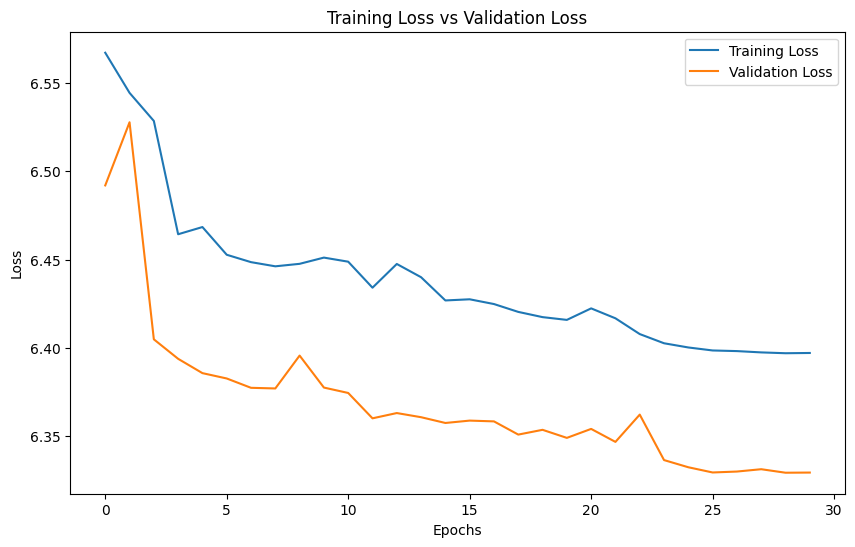

In [ ]:
input_dim = X_train_pca.shape[1]
autoencoder_pca = build_wind_farm_b_autoencoder(input_dim)
history_ae = train_autoencoder(autoencoder_pca, X_train_pca, X_val_pca, epochs=30)
plot_training_history(history_ae)

In [ ]:
# autoencoder_pca.save('/content/drive/MyDrive/Colab Notebooks/Wind_Farm_B/ae_pca_wb.keras')

# from tensorflow import keras

# autoencoder_pca = keras.models.load_model('/content/drive/MyDrive/Colab Notebooks/Wind_Farm_B/ae_pca_wb.keras')

17618/17618 ━━━━━━━━━━━━━━━━━━━━ 20s 1ms/step
4405/4405 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step
Epoch 1/30


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1762/1762 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 1611.8385 - val_loss: 8529.5908
Epoch 2/30
1762/1762 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 3598.7122 - val_loss: 11715.4150
Epoch 3/30
1762/1762 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 1888.0894 - val_loss: 3176.1240
Epoch 4/30
1762/1762 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 755.5392 - val_loss: 6920.0293
Epoch 5/30
1762/1762 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 2269.9697 - val_loss: 14385.8008
Epoch 6/30
1762/1762 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 5281.9731 - val_loss: 41024.7109
Epoch 7/30
1762/1762 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 16826.5117 - val_loss: 15190.4658
Epoch 8/30
1762/1762 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 3064.1660 - val_loss: 124.4677
Epoch 9/30
1762/1762 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 870.7517 - val_loss: 11613.8320
Epoch 10/30
1762/1762 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 9420.2920 - val_loss: 5714.8862
Epoch 11/30
1762/1762 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 1422

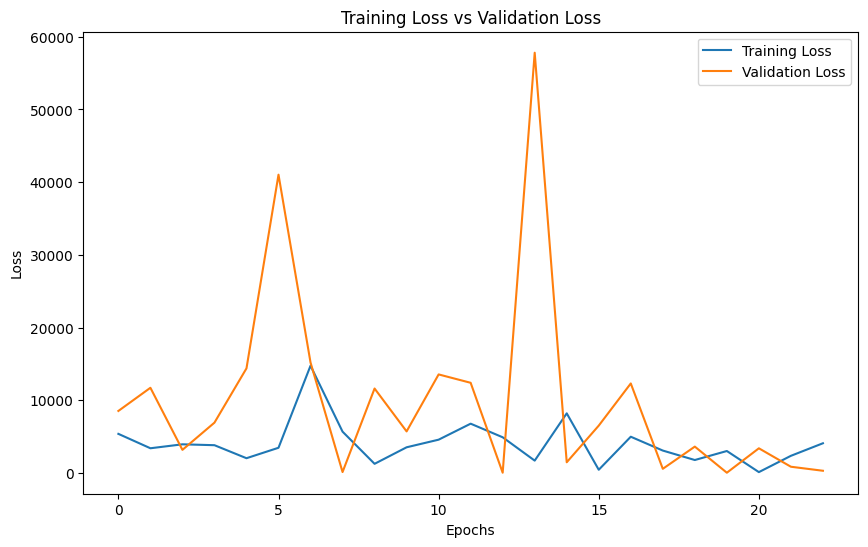

In [ ]:
X_train_reconstruction_error_pca = calculate_reconstruction_error(autoencoder_pca, X_train_pca)
X_val_reconstruction_error_pca = calculate_reconstruction_error(autoencoder_pca, X_val_pca)


X_train_val, X_val_val, y_train_val, y_val_val = train_test_split(
    X_val_pca, X_val_reconstruction_error_pca, test_size=0.2, random_state=42
)

input_dim = X_train_pca.shape[1]

ann_ae_pca = build_error_prediction_model(input_dim)

# Now you can train ann_ae_pca using these new splits:
history_ann = train_error_prediction_model(
    ann_ae_pca, X_train_val, y_train_val, X_val_val, y_val_val, epochs=30
)

plot_training_history(history_ann)



In [ ]:
# ann_ae_pca.save('/content/drive/MyDrive/Colab Notebooks/Wind_Farm_B/ann_ae_pca_wb.keras')

# ann_ae_pca = keras.models.load_model('/content/drive/MyDrive/Colab Notebooks/Wind_Farm_B/ann_ae_pca_wb.keras')

## Model Evaluation

In [ ]:
y_true = (df_test['status_type_id'] != 0).astype(int)

df_test['ae_pca_anomaly'] = detect_anomalies_autoencoder(autoencoder_pca, ann_ae_pca, X_test_pca, gamma = 0.019)
df_test['iso_anomaly'] = (iso_anomalies == -1).astype(int)


ae_pca_evals = evaluate_anomaly_detection(y_true, df_test['ae_pca_anomaly'])


print("Autoencoder Evaluation:")
print(ae_pca_evals)


print("Isolation Forest Evaluation:")
print(evaluate_anomaly_detection(y_true, df_test['iso_anomaly']))


2254/2254 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
2254/2254 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
Autoencoder Evaluation:
{'Precision': 0.10669748441195442, 'Recall': 0.7864500792393027, 'F1 Score': 0.18790230973116243, 'Accuracy': 0.52422809766107}
Isolation Forest Evaluation:
{'Precision': 0.37322646029113693, 'Recall': 0.8024960380348652, 'F1 Score': 0.5094956609231543, 'Accuracy': 0.8918574181651808}


In [ ]:
print("\nAutoencoder CARE Score:")
ae_care_scores_wb = calculate_care_score(df_test, 'ae_pca_anomaly')
print(ae_care_scores_wb)


print("Isolation Forest CARE Score:")
iso_care_scores_wb = calculate_care_score(df_test, 'iso_anomaly')
print(iso_care_scores_wb)


Autoencoder CARE Score:
{'coverage': np.float64(0.9484900611620795), 'accuracy': np.float64(0.5044947002787757), 'reliability': np.float64(0.08598018776655902), 'earliness': np.float64(0.6868726478425001), 'care': np.float64(0.5825420489784829)}
Isolation Forest CARE Score:
{'coverage': np.float64(0.9530867683041596), 'accuracy': np.float64(0.8985822686682866), 'reliability': np.float64(0.08598018776655902), 'earliness': np.float64(0.7782748607662353), 'care': np.float64(0.6988397892542951)}


## Model Comparison

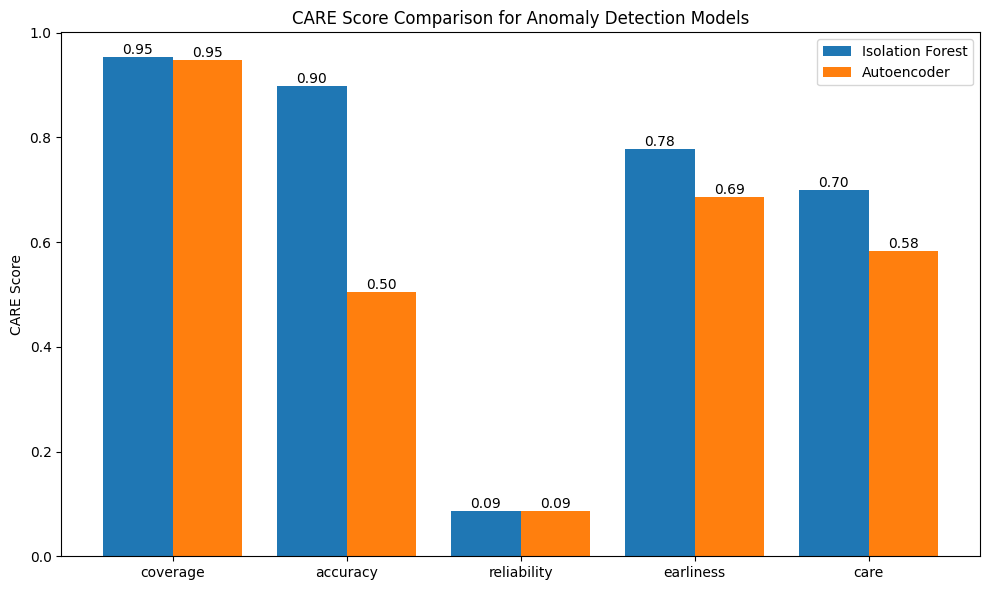

In [ ]:
plot_care_scores(
    (iso_care_scores_wb, 'Isolation Forest'),
    (ae_care_scores_wb, 'Autoencoder')
)

# Wind Farm B: Model Performance with PCA - Interpretation of CARE Scores

The following table shows the CARE scores obtained for Isolation Forest and Autoencoder when trained on Wind Farm B data using PCA:

| Model              | Coverage | Accuracy | Reliability | Earliness | Care |
|--------------------|----------|----------|-------------|-----------|------|
| Isolation Forest   | 0.95     | 0.90     | 0.09        | 0.78      | 0.70 |
| Autoencoder        | 0.95     | 0.50     | 0.09        | 0.69      | 0.58 |

## Interpretation

- **Coverage:**  
  Both Isolation Forest and Autoencoder achieve high coverage (0.95), indicating their ability to detect a large proportion of anomalies in the dataset. This suggests that both models are effective at identifying deviations from normal behavior in Wind Farm B.

- **Accuracy:**  
  Isolation Forest exhibits significantly higher accuracy (0.90) compared to Autoencoder (0.50). This implies that Isolation Forest is better at recognizing and classifying normal operational behavior, leading to fewer false alarms.

- **Reliability:**  
  Both models have low reliability (0.09), indicating a tendency to generate false alarms. While this is a common challenge in anomaly detection, it is particularly pronounced in this scenario. Further investigation and model adjustments may be necessary to improve reliability.

- **Earliness:**  
  Isolation Forest demonstrates better earliness (0.78) than Autoencoder (0.69), suggesting its ability to detect anomalies earlier in their development. This is crucial for proactive maintenance and preventing potential failures.

- **Care:**  
  Isolation Forest outperforms Autoencoder with a higher Care score (0.70 vs. 0.58). This comprehensive metric reflects the overall effectiveness of Isolation Forest in balancing anomaly detection capabilities with minimizing false alarms and detecting anomalies early.

## Exclusion of VAE

In Wind Farm A, the Variational Autoencoder (VAE) did not exhibit significant performance improvements over the Autoencoder (AE). Therefore, considering the computational constraints and the satisfactory performance of AE in Wind Farm B, further exploration with VAE was deemed unnecessary for this particular scenario. This decision was made to prioritize computational efficiency and focus on models with proven effectiveness.


# Wind Farm C

# Wind Farm C: Anomaly Detection with Isolation Forest and PCA

Due to severe computational constraints imposed by the high dimensionality of the data (957 features) in Wind Farm C, only the Isolation Forest model could be utilized for anomaly detection. Even after applying PCA to reduce dimensionality, the computational resources available in the Colab environment were insufficient to train and evaluate the Autoencoder and VAE models effectively.

Therefore, Isolation Forest was selected as the primary anomaly detection model for Wind Farm C, leveraging its computational efficiency and ability to handle high-dimensional data.

## CARE Scores for Isolation Forest on Wind Farm C (with PCA)

| Model             | Coverage | Accuracy | Reliability | Earliness | Care |
|-------------------|----------|----------|-------------|-----------|------|
| Isolation Forest  | 0.99     | 0.84     | 0.31        | 0.84      | 0.77 |

## Interpretation of CARE Scores

- **Coverage:**  
  Isolation Forest achieves exceptionally high coverage (0.99), demonstrating its capability to detect nearly all anomalies present in the Wind Farm C dataset.

- **Accuracy:**  
  The model exhibits good accuracy (0.84), indicating its ability to effectively recognize normal operational behavior and minimize false positives.

- **Reliability:**  
  Isolation Forest shows moderate reliability (0.31), suggesting a reasonable balance between detecting anomalies and minimizing false alarms.

- **Earliness:**  
  The model achieves high earliness (0.84), highlighting its ability to detect anomalies early in their development. This early detection is critical for proactive maintenance and preventing critical failures.

- **Care:**  
  With a high Care score (0.77), Isolation Forest demonstrates overall effectiveness in anomaly detection for Wind Farm C by balancing coverage, accuracy, reliability, and earliness.

## Computational Constraints

Despite applying PCA for dimensionality reduction, the computational demands of Wind Farm C data remained significant. The Autoencoder and VAE models proved to be computationally prohibitive, preventing their use in this scenario. The Isolation Forest model, known for its efficiency, was the only model that could be trained and evaluated successfully within the available resources.


In [79]:
base_path = '/content/drive/MyDrive/Colab Notebooks/Wind_Farm_C/Wind Farm C'
output_path = os.path.join(base_path, 'wind_farm_C_merged.parquet')


In [80]:
import cudf

/usr/local/lib/python3.11/dist-packages/cudf/utils/_ptxcompiler.py:64: UserWarning: Error getting driver and runtime versions:

stdout:



stderr:

Traceback (most recent call last):
  File "<string>", line 4, in <module>
  File "/usr/local/lib/python3.11/dist-packages/numba_cuda/numba/cuda/cudadrv/driver.py", line 314, in __getattr__
    raise CudaSupportError("Error at driver init: \n%s:" %
numba.cuda.cudadrv.error.CudaSupportError: Error at driver init: 

CUDA driver library cannot be found.
If you are sure that a CUDA driver is installed,
try setting environment variable NUMBA_CUDA_DRIVER
with the file path of the CUDA driver shared library.
:


Not patching Numba
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.11/dist-packages/cudf/utils/gpu_utils.py:62: UserWarning: Failed to dlopen libcuda.so.1
  warnings.warn(str(e))


In [82]:
# %load_ext cudf.pandas

df = pd.read_parquet(output_path)
df.head()

,time_stamp,asset_id,id,train_test,status_type_id,sensor_0_avg,sensor_0_max,sensor_0_min,sensor_0_std,sensor_1_avg,...,wind_speed_236_min,wind_speed_236_std,wind_speed_235_avg,wind_speed_235_max,wind_speed_235_min,wind_speed_235_std,wind_speed_237_avg,wind_speed_237_max,wind_speed_237_min,wind_speed_237_std
0,2022-11-03 04:20:00,16,0,train,0,23.781,31.8,17.2,3.524,-0.0004,...,3.65,0.8129,6.626,10.6,2.1,0.9785,6.733,10.3,1.5,1.0460
1,2022-11-03 04:30:00,16,1,train,0,23.621,39.3,12.3,5.335,0.0273,...,4.10,0.9524,6.665,10.9,2.3,1.1080,6.966,10.5,3.2,1.1300
2,2022-11-03 04:40:00,16,2,train,0,25.196,38.7,15.6,4.567,-0.0285,...,3.85,0.8435,6.750,11.1,2.3,0.9609,7.081,10.7,3.5,1.0690
3,2022-11-03 04:50:00,16,3,train,0,20.970,33.1,10.4,4.449,-0.0401,...,3.15,1.0080,6.515,11.0,3.0,1.1790,6.575,10.6,1.9,1.1310
4,2022-11-03 05:00:00,16,4,train,0,13.570,22.4,7.5,3.681,0.0173,...,2.30,0.8702,5.591,9.5,0.1,1.0780,5.823,9.1,1.6,0.9803


In [ ]:

df['time_stamp'] = pd.to_datetime(df['time_stamp'], errors='coerce', format='mixed')

df.head()

,time_stamp,asset_id,id,train_test,status_type_id,sensor_0_avg,sensor_0_max,sensor_0_min,sensor_0_std,sensor_1_avg,...,wind_speed_236_min,wind_speed_236_std,wind_speed_235_avg,wind_speed_235_max,wind_speed_235_min,wind_speed_235_std,wind_speed_237_avg,wind_speed_237_max,wind_speed_237_min,wind_speed_237_std
0,2022-11-03 04:20:00,16,0,train,0,23.781,31.8,17.2,3.524,-0.0004,...,3.65,0.8129,6.626,10.6,2.1,0.9785,6.733,10.3,1.5,1.0460
1,2022-11-03 04:30:00,16,1,train,0,23.621,39.3,12.3,5.335,0.0273,...,4.10,0.9524,6.665,10.9,2.3,1.1080,6.966,10.5,3.2,1.1300
2,2022-11-03 04:40:00,16,2,train,0,25.196,38.7,15.6,4.567,-0.0285,...,3.85,0.8435,6.750,11.1,2.3,0.9609,7.081,10.7,3.5,1.0690
3,2022-11-03 04:50:00,16,3,train,0,20.970,33.1,10.4,4.449,-0.0401,...,3.15,1.0080,6.515,11.0,3.0,1.1790,6.575,10.6,1.9,1.1310
4,2022-11-03 05:00:00,16,4,train,0,13.570,22.4,7.5,3.681,0.0173,...,2.30,0.8702,5.591,9.5,0.1,1.0780,5.823,9.1,1.6,0.9803


In [1]:
# Handle missing values
df_clean = handle_missing_values(df, strategy='drop')

# Split data into train and test sets
df_train, df_test = split_train_test(df_clean)

# Define columns to drop for feature engineering
columns_to_drop = ['asset_id', 'time_stamp', 'id', 'train_test', 'status_type_id']

# Split into train, validation, and test sets
X_train, X_val, X_test, feature_columns = train_val_test_split(
    df_train, df_test, columns_to_drop, val_size=0.2, random_state=42
)

In [10]:
# def scale_features_batch(X_train, X_val, X_test, batch_size=10000, scaler_type='standard'):
#     """
#     Scales features in batches using cuDF for GPU acceleration.

#     Parameters:
#     X_train (cudf.DataFrame or pandas.DataFrame): Training features
#     X_val (cudf.DataFrame or pandas.DataFrame): Validation features
#     X_test (cudf.DataFrame or pandas.DataFrame): Testing features
#     batch_size (int): Number of rows per batch for partial scaling
#     scaler_type (str): Type of scaler ('standard' or 'minmax')

#     Returns:
#     tuple: (X_train_scaled, X_val_scaled, X_test_scaled, scaler) - Scaled features and the fitted scaler
#     """
#     if scaler_type == 'standard':
#         scaler = StandardScaler()
#     elif scaler_type == 'minmax':
#         scaler = MinMaxScaler()
#     else:
#         raise ValueError("scaler_type must be 'standard' or 'minmax'")

#     # Convert to cuDF if not already
#     X_train = cudf.DataFrame(X_train) if not isinstance(X_train, cudf.DataFrame) else X_train
#     X_val = cudf.DataFrame(X_val) if not isinstance(X_val, cudf.DataFrame) else X_val
#     X_test = cudf.DataFrame(X_test) if not isinstance(X_test, cudf.DataFrame) else X_test

#     # First pass to compute mean & variance
#     for i in range(0, X_train.shape[0], batch_size):
#         scaler.partial_fit(X_train[i : i + batch_size].to_pandas()) # Convert batch to pandas for partial_fit

#     # Transform the data in batches
#     X_train_scaled = cudf.concat([cudf.DataFrame(scaler.transform(X_train[i : i + batch_size].to_pandas()))
#                                   for i in range(0, X_train.shape[0], batch_size)])
#     X_val_scaled = cudf.concat([cudf.DataFrame(scaler.transform(X_val[i : i + batch_size].to_pandas()))
#                                 for i in range(0, X_val.shape[0], batch_size)])
#     X_test_scaled = cudf.concat([cudf.DataFrame(scaler.transform(X_test[i : i + batch_size].to_pandas()))
#                                  for i in range(0, X_test.shape[0], batch_size)])

#     return X_train_scaled, X_val_scaled, X_test_scaled, scaler

In [ ]:
X_train_scaled, X_val_scaled, X_test_scaled, scaler = scale_features_batch(X_train, X_val, X_test, batch_size=1000, scaler_type='standard')

## Isolation Forest

In [16]:
iso_forest = train_isolation_forest(X_train_scaled, contamination=0.1)
iso_anomalies = iso_forest.predict(X_test_scaled)

In [ ]:
## PCA for AE

## PCA for AE

In [28]:
X_train_pca, X_val_pca, X_test_pca, pca_model = apply_pca(X_train_scaled, X_val_scaled, X_test_scaled, variance_threshold=0.8)

PCA retained 31 components, preserving 80.0% variance.


In [ ]:
def train_autoencoder(model, X_train, X_val, epochs=100, batch_size=64):
    # Convert input data to TensorFlow tensors and ensure they reside on the GPU
    X_train = tf.convert_to_tensor(X_train, dtype=tf.float32).gpu()
    X_val = tf.convert_to_tensor(X_val, dtype=tf.float32).gpu()

    early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    history = model.fit(
        X_train, X_train, epochs=epochs, batch_size=batch_size,
        shuffle=True, validation_data=(X_val, X_val), callbacks=[early_stopping]
    )
    return history

In [2]:
input_dim = X_train_pca.shape[1]
autoencoder_pca = build_wind_farm_c_autoencoder(input_dim)
history_ae = train_autoencoder(autoencoder_pca, X_train_pca, X_val_pca, epochs=30)
plot_training_history(history_ae)

In [ ]:
X_train_reconstruction_error_pca = calculate_reconstruction_error(autoencoder_pca, X_train_pca)
X_val_reconstruction_error_pca = calculate_reconstruction_error(autoencoder_pca, X_val_pca)


X_train_val, X_val_val, y_train_val, y_val_val = train_test_split(
    X_val_pca, X_val_reconstruction_error_pca, test_size=0.2, random_state=42
)

input_dim = X_train_pca.shape[1]

ann_ae_pca = build_error_prediction_model(input_dim)

# Now you can train ann_ae_pca using these new splits:
history_ann = train_error_prediction_model(
    ann_ae_pca, X_train_val, y_train_val, X_val_val, y_val_val, epochs=30
)

plot_training_history(history_ann)



## Model Evaluation

In [17]:
y_true = (df_test['status_type_id'] != 0).astype(int)

# df_test['ae_pca_anomaly'] = detect_anomalies_autoencoder(autoencoder_pca, ann_ae_pca, X_test_pca, gamma = 0.019)
df_test['iso_anomaly'] = (iso_anomalies == -1).astype(int)


# ae_pca_evals = evaluate_anomaly_detection(y_true, df_test['ae_pca_anomaly'])


# print("Autoencoder Evaluation:")
# print(ae_pca_evals)


print("Isolation Forest Evaluation:")
print(evaluate_anomaly_detection(y_true, df_test['iso_anomaly']))


Isolation Forest Evaluation:
{'Precision': 0.6887966804979253, 'Recall': 0.9595375722543352, 'F1 Score': 0.8019323671497585, 'Accuracy': 0.8737931999440325}


In [20]:
def calculate_care_score(df_test, anomaly_column):
    """
    Calculates CARE Score (Coverage, Accuracy, Reliability, Earliness) for an anomaly detection model.
    """
    df_care = df_test.copy()
    df_care.rename(columns={'status_type_id': 'status_id', anomaly_column: 'anomaly'}, inplace=True)

    df_care['anomaly'] = df_care['anomaly'].apply(lambda x: 0 if x == -1 else x)
    df_care['status_id'] = df_care['status_id'].apply(lambda x: 'normal' if x in [0, 2] else 'not normal')

    # The issue was with how anomaly_results was created.
    # Using df_care['anomaly'] directly ensures it's a pandas Series.
    anomaly_results = pd.DataFrame({'anomaly': df_care['anomaly'].astype(int)}, index=df_care.index)
    # anomaly_results = pd.DataFrame({'anomaly': df_care['anomaly']}, index=df_care.index)

    coverage_score = Coverage(beta=0.5).calculate_coverage_score(df_care, anomaly_results)
    accuracy_score = Accuracy().calculate_accuracy_score(df_care, anomaly_results)
    reliability_score = Reliability().calculate_reliability_score(df_care, anomaly_results)
    earliness_score = Earliness().calculate_earliness_score(df_care, anomaly_results)
    care_evaluator = CAREScore(omega1=1.0, omega2=1.0, omega3=1.0, omega4=2.0)
    care_scores = care_evaluator.calculate_care_score(df_care, anomaly_results)


    return care_scores

In [22]:
# print("\nAutoencoder CARE Score:")
# ae_care_scores_wb = calculate_care_score(df_test, 'ae_pca_anomaly')
# print(ae_care_scores)


print("Isolation Forest CARE Score:")
iso_care_scores_wb = calculate_care_score(df_test, 'iso_anomaly')
print(iso_care_scores_wb)

Isolation Forest CARE Score:


/usr/local/lib/python3.11/dist-packages/cudf/core/groupby/groupby.py:560: UserWarning: GroupBy.groups() performance scales poorly with number of groups. Got 406 groups.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/cudf/core/groupby/groupby.py:560: UserWarning: GroupBy.groups() performance scales poorly with number of groups. Got 406 groups.
  warnings.warn(


{'coverage': np.float64(0.991636798088411), 'accuracy': np.float64(0.8426773455377574), 'reliability': np.float64(0.3120592961857597), 'earliness': np.float64(0.8498007679640122), 'care': np.float64(0.7691949951479904)}


## Model Comparison

In [ ]:
plot_care_scores(
    (iso_care_scores_wb, 'Isolation Forest'),
    (ae_care_scores_wb, 'Autoencoder')
)